# 📧 ĐỒ ÁN PHÂN LOẠI EMAIL SPAM/HAM
## BiLSTM (Baseline) vs BERT MoE (Nâng cao)
**Model BERT MoE:** `AntiSpamInstitute/spam-detector-bert-MoE-v2.2`

### Cấu trúc notebook:
| Phần | Nội dung |
|------|----------|
| 0 | Mount Drive & Cài đặt thư viện |
| 1 | Tải & Khám phá dữ liệu |
| 2 | Phân tích dữ liệu chi tiết (EDA) |
| 3 | Tiền xử lý dữ liệu |
| 4 | Tokenization & Chia tập dữ liệu |
| 5–6 | Mô hình 1 – BiLSTM Baseline (xây dựng + huấn luyện) |
| 7 | Learning Curves & Đánh giá BiLSTM |
| 8–9 | Thí nghiệm BiLSTM (SGD / Weight Decay) |
| 10 | Bảng so sánh BiLSTM |
| 11 | Mô hình 2 – BERT MoE: Chuẩn bị dữ liệu |
| 12 | BERT MoE: Hàm training & đánh giá |
| 13 | BERT MoE (AdamW – Full Fine-tune) |
| 14 | Thí nghiệm BERT MoE (SGD) |
| 15 | Thí nghiệm BERT MoE (Frozen Encoder) |
| 16 | Tổng hợp so sánh tất cả mô hình |
| 17 | Lưu & Load Model |
| 18–19 | Demo phát hiện spam + Demo tương tác |
| 20 | Phân tích lỗi điển hình |

## PHẦN 0: MOUNT GOOGLE DRIVE & CÀI ĐẶT THƯ VIỆN

In [ ]:
# ============================================================
# PHẦN 0: MOUNT GOOGLE DRIVE & CÀI ĐẶT THƯ VIỆN
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/email_spam_bertmoe'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Thư mục lưu model: {SAVE_DIR}")

# Cài đặt thư viện cần thiết
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy
!pip install -q transformers torch accelerate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# TensorFlow (cho BiLSTM Baseline)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# PyTorch + HuggingFace Transformers (cho BERT MoE)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer as HFTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version : {tf.__version__}")
print(f"PyTorch version    : {torch.__version__}")
print(f"GPU (TF)           : {tf.config.list_physical_devices('GPU')}")
print(f"GPU (Torch)        : {torch.cuda.is_available()} – {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ PyTorch device: {DEVICE}")

# Seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
✅ Thư mục lưu model: /content/drive/MyDrive/email_spam_bertmoe
TensorFlow version : 2.20.0
PyTorch version    : 2.10.0+cu128
GPU (TF)           : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (Torch)        : True – Tesla T4

✅ PyTorch device: cuda


## TẢI VÀ PHÂN TÍCH DỮ LIỆU

In [ ]:
# ============================================================
# PHẦN 1: TẢI VÀ KHÁM PHÁ DỮ LIỆU
# ============================================================
# 📌 Upload file spam_ham_dataset.csv lên Google Drive trước
# Download tại: https://www.kaggle.com/datasets/venky73/spam-mails-dataset

DATA_PATH = '/content/drive/MyDrive/email_spam_bertmoe/spam_ham_dataset.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("📊 THÔNG TIN TỔNG QUAN VỀ DATASET")
print("=" * 60)
print(f"\n📌 Kích thước dataset: {df.shape[0]} mẫu, {df.shape[1]} cột")
print(f"\n📌 Các cột trong dataset:")
print(df.dtypes)
print(f"\n📌 5 mẫu đầu tiên:")
df.head()

📊 THÔNG TIN TỔNG QUAN VỀ DATASET

📌 Kích thước dataset: 5171 mẫu, 4 cột

📌 Các cột trong dataset:
Unnamed: 0     int64
label         object
text          object
label_num      int64
dtype: object

📌 5 mẫu đầu tiên:


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


📊 THỐNG KÊ SỐ LƯỢNG MẪU THEO LỚP

📌 Phân bố lớp:
   Ham  (không spam): 3672 mẫu (71.0%)
   Spam (thư rác)   : 1499 mẫu (29.0%)
   Tỷ lệ Ham:Spam   = 2.45:1

⚠️  Dataset MẤT CÂN BẰNG: Lớp ham nhiều gấp ~2.4 lần lớp spam


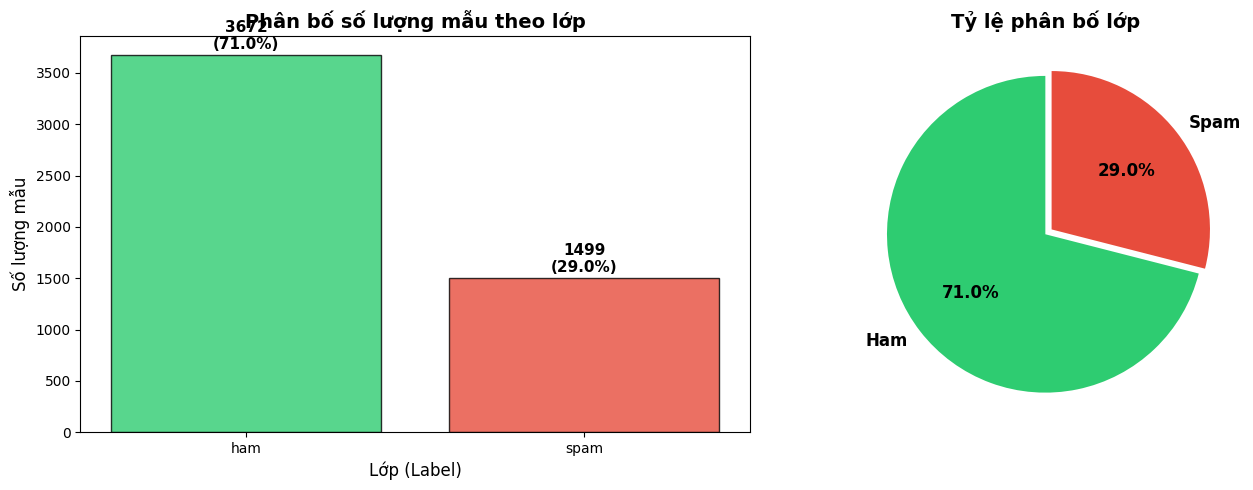


📊 THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ)

📌 Lớp HAM:
   Min: 2, Max: 8862
   Mean: 225.2, Median: 123.0
   Std: 332.1
   Quantile 25%: 50, 75%: 293, 95%: 733

📌 Lớp SPAM:
   Min: 1, Max: 3962
   Mean: 234.1, Median: 114.0
   Std: 345.4
   Quantile 25%: 54, 75%: 242, 95%: 884


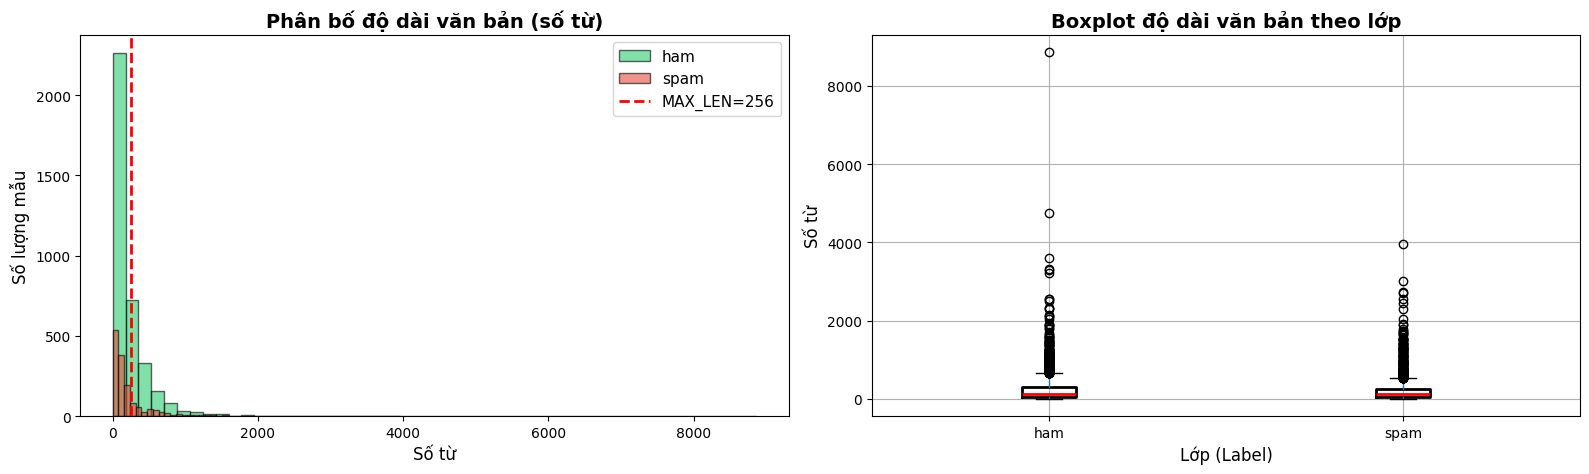


📊 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

📌 Dữ liệu thiếu (null):
Unnamed: 0     0
label          0
text           0
label_num      0
text_length    0
char_length    0
dtype: int64

📌 Số mẫu trùng lặp: 178

📌 Nhận xét các khó khăn đặc thù:
   1. ⚠️  Mất cân bằng lớp: Ham >> Spam → Cần class weight
   2. ⚠️  Độ dài chuỗi biến thiên lớn → Cần padding/truncating
   3. ⚠️  Dữ liệu email chứa HTML tags, ký tự đặc biệt → Cần tiền xử lý
   4. ⚠️  Có thể có mẫu trùng lặp → Cần loại bỏ


In [ ]:
# ============================================================
# PHẦN 2: PHÂN TÍCH DỮ LIỆU CHI TIẾT (EDA)
# ============================================================

print("=" * 60)
print("📊 THỐNG KÊ SỐ LƯỢNG MẪU THEO LỚP")
print("=" * 60)

# 2.1 Thống kê phân bố lớp
class_counts = df['label'].value_counts()
print(f"\n📌 Phân bố lớp:")
print(f"   Ham  (không spam): {class_counts['ham']} mẫu ({class_counts['ham']/len(df)*100:.1f}%)")
print(f"   Spam (thư rác)   : {class_counts['spam']} mẫu ({class_counts['spam']/len(df)*100:.1f}%)")
print(f"   Tỷ lệ Ham:Spam   = {class_counts['ham']/class_counts['spam']:.2f}:1")
print(f"\n⚠️  Dataset MẤT CÂN BẰNG: Lớp ham nhiều gấp ~{class_counts['ham']/class_counts['spam']:.1f} lần lớp spam")

# 2.2 Biểu đồ phân bố lớp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Phân bố số lượng mẫu theo lớp', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lớp (Label)', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'{count}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].pie(class_counts.values, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Tỷ lệ phân bố lớp', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.3 Phân tích độ dài chuỗi
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_length'] = df['text'].apply(lambda x: len(str(x)))

print("\n" + "=" * 60)
print("📊 THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ)")
print("=" * 60)

for label in ['ham', 'spam']:
    subset = df[df['label'] == label]['text_length']
    print(f"\n📌 Lớp {label.upper()}:")
    print(f"   Min: {subset.min()}, Max: {subset.max()}")
    print(f"   Mean: {subset.mean():.1f}, Median: {subset.median():.1f}")
    print(f"   Std: {subset.std():.1f}")
    print(f"   Quantile 25%: {subset.quantile(0.25):.0f}, 75%: {subset.quantile(0.75):.0f}, 95%: {subset.quantile(0.95):.0f}")

# 2.4 Biểu đồ phân bố độ dài
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='black')
axes[0].set_title('Phân bố độ dài văn bản (số từ)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số từ', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].axvline(x=256, color='red', linestyle='--', linewidth=2, label='MAX_LEN=256')
axes[0].legend(fontsize=11)

df.boxplot(column='text_length', by='label', ax=axes[1],
           boxprops=dict(linewidth=2), medianprops=dict(linewidth=2, color='red'))
axes[1].set_title('Boxplot độ dài văn bản theo lớp', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lớp (Label)', fontsize=12)
axes[1].set_ylabel('Số từ', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.5 Kiểm tra dữ liệu thiếu và trùng lặp
print("\n" + "=" * 60)
print("📊 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("=" * 60)
print(f"\n📌 Dữ liệu thiếu (null):")
print(df.isnull().sum())
print(f"\n📌 Số mẫu trùng lặp: {df.duplicated(subset=['text']).sum()}")
print(f"\n📌 Nhận xét các khó khăn đặc thù:")
print("   1. ⚠️  Mất cân bằng lớp: Ham >> Spam → Cần class weight")
print("   2. ⚠️  Độ dài chuỗi biến thiên lớn → Cần padding/truncating")
print("   3. ⚠️  Dữ liệu email chứa HTML tags, ký tự đặc biệt → Cần tiền xử lý")
print("   4. ⚠️  Có thể có mẫu trùng lặp → Cần loại bỏ")

## TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
# ============================================================
# PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU
# ============================================================

print("=" * 60)
print("🔧 TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 60)

# 3.1 Loại bỏ mẫu trùng lặp
df_clean = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"\n📌 Sau khi loại trùng lặp: {len(df_clean)} mẫu (loại {len(df) - len(df_clean)} mẫu)")

# 3.2 Hàm tiền xử lý văn bản email
def preprocess_email(text):
    """
    Tiền xử lý email:
    1. Loại bỏ HTML tags
    2. Loại bỏ URL
    3. Loại bỏ email addresses
    4. Loại bỏ số điện thoại
    5. Loại bỏ ký tự đặc biệt
    6. Chuyển về chữ thường
    7. Loại bỏ khoảng trắng thừa
    """
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Áp dụng tiền xử lý (dùng cho BiLSTM)
df_clean['clean_text'] = df_clean['text'].apply(preprocess_email)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].reset_index(drop=True)

# Encode nhãn
df_clean['label_num'] = (df_clean['label'] == 'spam').astype(int)

print(f"📌 Sau tiền xử lý: {len(df_clean)} mẫu")

# Hiển thị ví dụ trước và sau tiền xử lý
print(f"\n📌 Ví dụ tiền xử lý:")
for i in range(3):
    print(f"\n--- Mẫu {i+1} ({df_clean.iloc[i]['label']}) ---")
    print(f"  Gốc : {df_clean.iloc[i]['text'][:150]}...")
    print(f"  Sạch: {df_clean.iloc[i]['clean_text'][:150]}...")

# Cập nhật thống kê sau tiền xử lý
df_clean['clean_text_length'] = df_clean['clean_text'].apply(lambda x: len(x.split()))
print(f"\n📌 Thống kê độ dài sau tiền xử lý:")
print(df_clean.groupby('label')['clean_text_length'].describe().round(1))

print("\n📌 GHI CHÚ QUAN TRỌNG:")
print("   • BiLSTM sẽ dùng 'clean_text' (đã lowercase, loại ký tự đặc biệt)")
print("   • BERT MoE sẽ dùng 'text' gốc (BERT tokenizer tự xử lý)")

🔧 TIỀN XỬ LÝ DỮ LIỆU

📌 Sau khi loại trùng lặp: 4993 mẫu (loại 178 mẫu)
📌 Sau tiền xử lý: 4990 mẫu

📌 Ví dụ tiền xử lý:

--- Mẫu 1 (ham) ---
  Gốc : Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by dar...
  Sạch: enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume p...

--- Mẫu 2 (ham) ---
  Gốc : Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls...
  Sạch: hpl nom for january see attached file hplnol xls hplnol xls...

--- Mẫu 3 (ham) ---
  Gốc : Subject: neon retreat
ho ho ho , we ' re around to that most wonderful time of the year - - - neon leaders retreat time !
i know that this time of y...
  Sạch: neon retreat ho ho ho we re around to that most wonderful time of the year neon leaders retreat time i know that this time of year is extremely hecti

In [ ]:
# ============================================================
# PHẦN 4: TOKENIZATION & CHIA TẬP DỮ LIỆU
# ============================================================

print("=" * 60)
print("🔧 TOKENIZATION & CHIA TẬP DỮ LIỆU")
print("=" * 60)

# 4.1 Cấu hình
MAX_WORDS = 30000   # Kích thước vocabulary (BiLSTM)
MAX_LEN = 256       # Độ dài tối đa chuỗi
EMBEDDING_DIM = 128 # Kích thước embedding vector

# 4.2 Tokenization (cho BiLSTM)
tokenizer_bilstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_bilstm.fit_on_texts(df_clean['clean_text'])

word_index = tokenizer_bilstm.word_index
print(f"\n📌 Tổng số từ vựng (unique words): {len(word_index)}")
print(f"📌 Số từ vựng sử dụng (MAX_WORDS): {MAX_WORDS}")

sequences = tokenizer_bilstm.texts_to_sequences(df_clean['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df_clean['label_num'].values

print(f"\n📌 Kích thước X (padded sequences): {X.shape}")
print(f"📌 Kích thước y (labels): {y.shape}")

# 4.3 Chia tập train/validation/test (70/15/15)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full
)

print(f"\n📌 Chia tập dữ liệu (stratified):")
print(f"   Train     : {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} mẫu ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test      : {X_test.shape[0]} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")

for name, labels in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    spam_ratio = labels.sum() / len(labels) * 100
    print(f"   {name:10s}: Ham={100-spam_ratio:.1f}%, Spam={spam_ratio:.1f}%")

# 4.4 Tính class weight để xử lý mất cân bằng
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print(f"\n📌 Class weights (xử lý mất cân bằng):")
print(f"   Ham (0) : {class_weight_dict[0]:.4f}")
print(f"   Spam (1): {class_weight_dict[1]:.4f}")

# Lưu tokenizer
tokenizer_path = os.path.join(SAVE_DIR, 'tokenizer_bilstm.pickle')
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer_bilstm, f)
print(f"\n✅ Đã lưu tokenizer tại: {tokenizer_path}")

🔧 TOKENIZATION & CHIA TẬP DỮ LIỆU

📌 Tổng số từ vựng (unique words): 45769
📌 Số từ vựng sử dụng (MAX_WORDS): 30000

📌 Kích thước X (padded sequences): (4990, 256)
📌 Kích thước y (labels): (4990,)

📌 Chia tập dữ liệu (stratified):
   Train     : 3604 mẫu (72.2%)
   Validation: 637 mẫu (12.8%)
   Test      : 749 mẫu (15.0%)
   Train     : Ham=70.8%, Spam=29.2%
   Validation: Ham=70.8%, Spam=29.2%
   Test      : Ham=70.8%, Spam=29.2%

📌 Class weights (xử lý mất cân bằng):
   Ham (0) : 0.7067
   Spam (1): 1.7097

✅ Đã lưu tokenizer tại: /content/drive/MyDrive/email_spam_bertmoe/tokenizer_bilstm.pickle


## MÔ HÌNH 1 – BASELINE: BiLSTM

In [ ]:
# ============================================================
# PHẦN 5: MÔ HÌNH 1 – BASELINE: BiLSTM + Embedding + Pooling
# ============================================================

print("=" * 60)
print("🧠 MÔ HÌNH 1: BiLSTM + Embedding + GlobalMaxPooling (Baseline)")
print("=" * 60)

def build_bilstm_model(optimizer_name='adam', dropout_rate=0.5, use_weight_decay=False):
    """
    Mô hình Baseline: BiLSTM
    - Embedding layer
    - Bidirectional LSTM
    - Global Max Pooling
    - Dense layers với Dropout
    - Binary Cross-Entropy Loss
    """
    inputs = layers.Input(shape=(MAX_LEN,), name='input')

    # Embedding layer
    x = layers.Embedding(input_dim=MAX_WORDS,
                         output_dim=EMBEDDING_DIM,
                         input_length=MAX_LEN,
                         name='embedding')(inputs)

    # Spatial Dropout (regularization cho embedding)
    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # Bidirectional LSTM
    x = layers.Bidirectional(
        layers.LSTM(64, recurrent_dropout=0.2, return_sequences=True, name='lstm'),
        name='bidirectional_lstm'
    )(x)

    # Global Max Pooling
    x = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

    # Dense layers
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    x = layers.Dense(32, activation='relu', name='dense_2')(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_Baseline')

    # Chọn optimizer
    if optimizer_name == 'adam':
        if use_weight_decay:
            optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, use_weight_decay=True)
        else:
            optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

model_bilstm = build_bilstm_model(optimizer_name='adam', dropout_rate=0.5)
model_bilstm.summary()

total_params = model_bilstm.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model_bilstm.trainable_weights])
print(f"\n📌 Tổng số tham số: {total_params:,}")
print(f"📌 Số tham số trainable: {trainable_params:,}")

🧠 MÔ HÌNH 1: BiLSTM + Embedding + GlobalMaxPooling (Baseline)


Model: "BiLSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 256, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 256, 128)       │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,949,185 (15.06 MB)

 Trainable params: 3,949,185 (15.06 MB)

 Non-trainable params: 0 (0.00 B)


📌 Tổng số tham số: 3,949,185
📌 Số tham số trainable: 3,949,185


In [ ]:
# ============================================================
# PHẦN 6: HUẤN LUYỆN MÔ HÌNH 1 – BiLSTM
# ============================================================

print("=" * 60)
print("🚀 HUẤN LUYỆN MÔ HÌNH 1: BiLSTM (Adam + Dropout)")
print("=" * 60)

BILSTM_MODEL_PATH = os.path.join(SAVE_DIR, 'bilstm_baseline.keras')
EPOCHS = 30
BATCH_SIZE = 32

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_bilstm,
    verbose=1
)

print(f"\n✅ Model BiLSTM đã lưu tại: {BILSTM_MODEL_PATH}")

🚀 HUẤN LUYỆN MÔ HÌNH 1: BiLSTM (Adam + Dropout)
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6667 - loss: 0.5468 - precision: 0.4824 - recall: 0.8136
Epoch 1: val_loss improved from None to 0.07875, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8169 - loss: 0.3537 - precision: 0.6310 - recall: 0.9004 - val_accuracy: 0.9702 - val_loss: 0.0788 - val_precision: 0.9326 - val_recall: 0.9677 - learning_rate: 0.0010
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9687 - loss: 0.0914 - precision: 0.9305 - recall: 0.9709
Epoch 2: val_loss improved from 0.07875 to 0.06250, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━

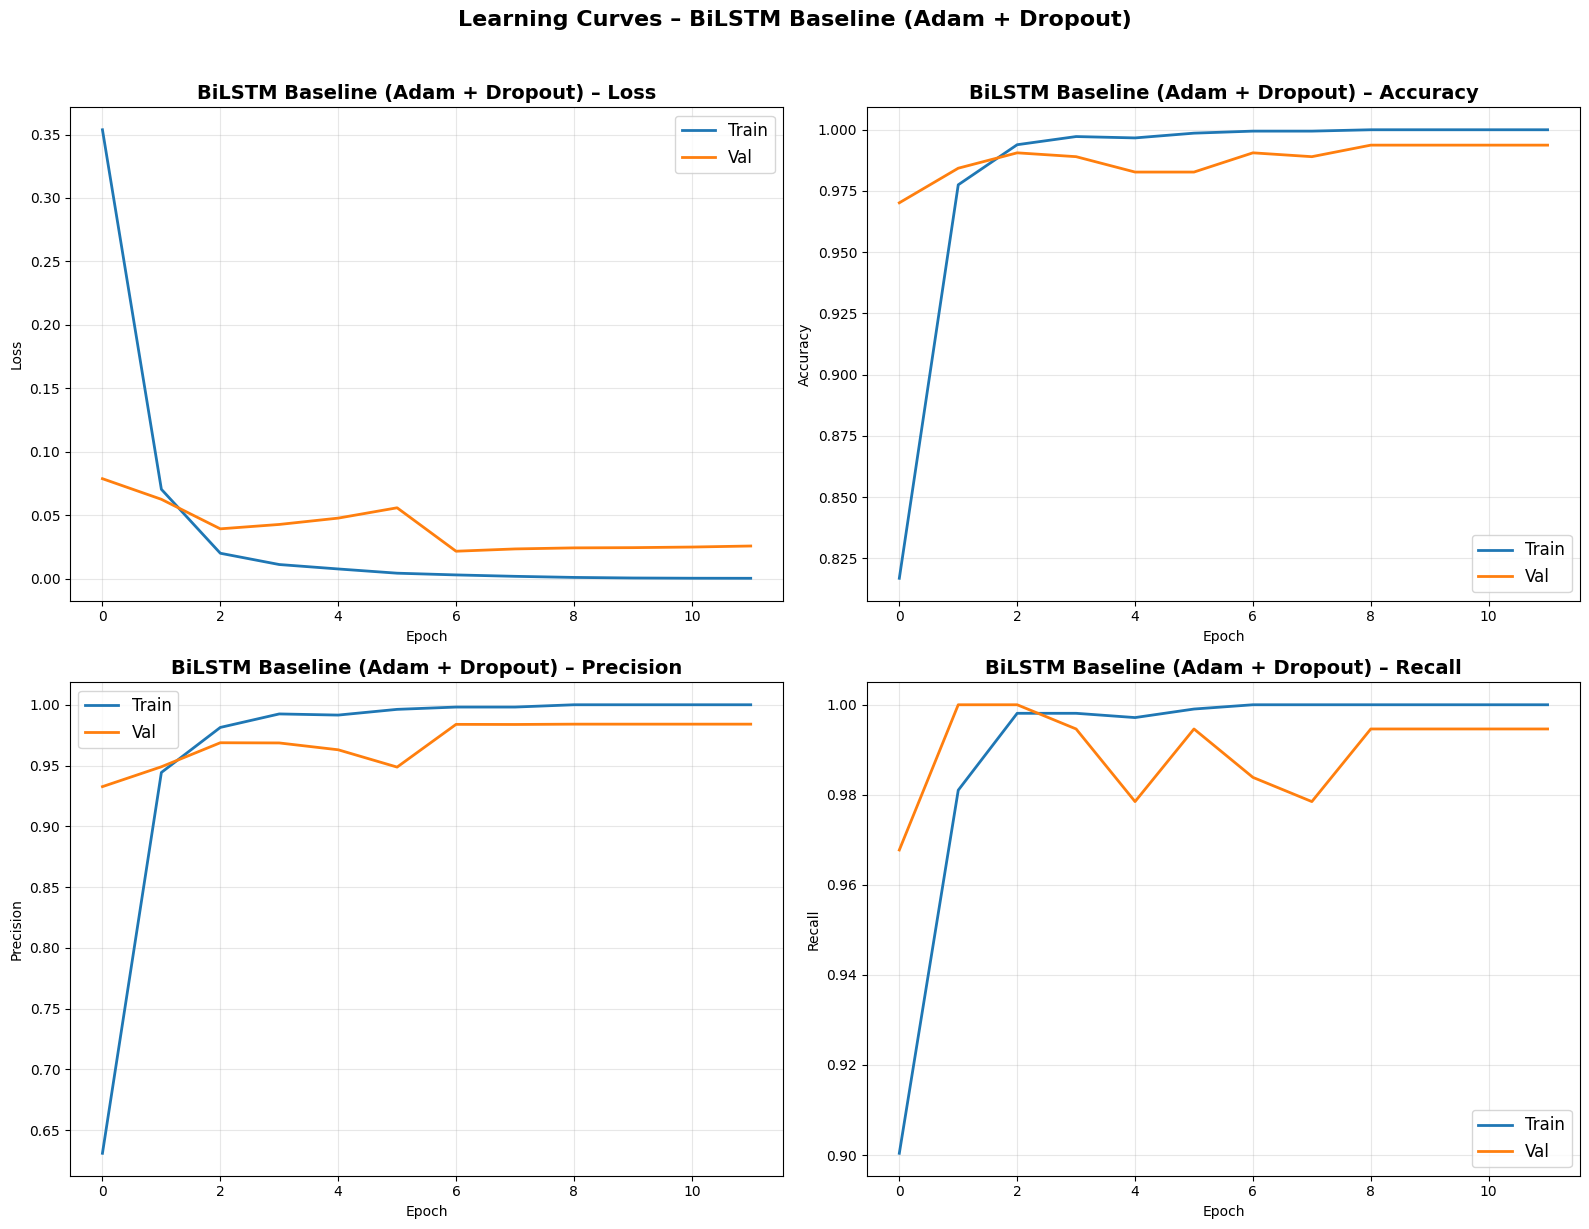


📊 ĐÁNH GIÁ BiLSTM Baseline TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9962    0.9868    0.9915       530
    Spam (1)     0.9688    0.9909    0.9797       219

    accuracy                         0.9880       749
   macro avg     0.9825    0.9888    0.9856       749
weighted avg     0.9882    0.9880    0.9880       749

📌 Accuracy : 0.9880
📌 Precision: 0.9688
📌 Recall   : 0.9909  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9797


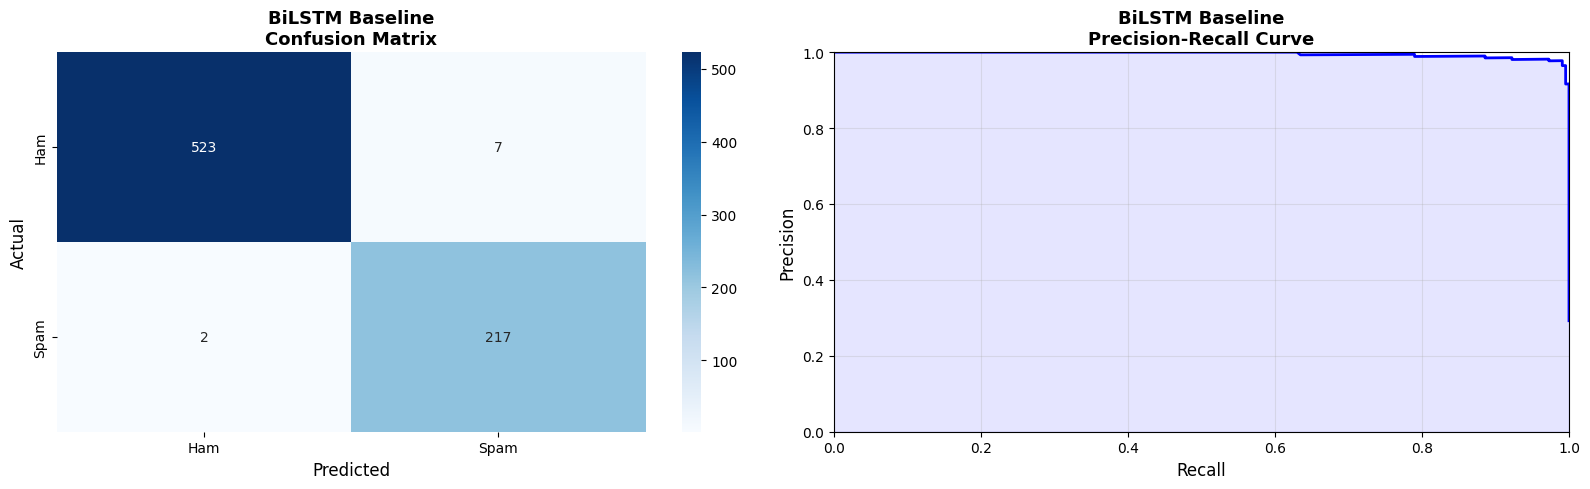

In [ ]:
# ============================================================
# PHẦN 7: VẼ LEARNING CURVES & ĐÁNH GIÁ MÔ HÌNH 1
# ============================================================

def plot_learning_curves(history, model_name, save_path=None):
    """Vẽ learning curves cho loss và các metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    metrics_pairs = [
        ('loss', 'val_loss', 'Loss'),
        ('accuracy', 'val_accuracy', 'Accuracy'),
        ('precision', 'val_precision', 'Precision'),
        ('recall', 'val_recall', 'Recall')
    ]

    for ax, (train_key, val_key, title) in zip(axes.flatten(), metrics_pairs):
        ax.plot(history.history[train_key], label='Train', linewidth=2)
        ax.plot(history.history[val_key], label='Val', linewidth=2)
        ax.set_title(f'{model_name} – {title}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Learning Curves – {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test, y_test, model_name, save_path=None):
    """Đánh giá model toàn diện trên tập test"""
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    print(f"\n{'='*60}")
    print(f"📊 ĐÁNH GIÁ {model_name} TRÊN TẬP TEST")
    print(f"{'='*60}")

    print(f"\n📌 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)'], digits=4))

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"📌 Accuracy : {acc:.4f}")
    print(f"📌 Precision: {prec:.4f}")
    print(f"📌 Recall   : {rec:.4f}  ← ƯU TIÊN (phát hiện spam)")
    print(f"📌 F1-Score : {f1:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_xlabel('Predicted', fontsize=12)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
    axes[1].plot(recall_vals, precision_vals, linewidth=2, color='blue')
    axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='blue')
    axes[1].set_title(f'{model_name}\nPrecision-Recall Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# Vẽ + Đánh giá BiLSTM Baseline
plot_learning_curves(history_bilstm, 'BiLSTM Baseline (Adam + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm.png')

results_bilstm = evaluate_model(model_bilstm, X_test, y_test, 'BiLSTM Baseline',
                                 save_path=f'{SAVE_DIR}/eval_bilstm.png')

## THÍ NGHIỆM SO SÁNH OPTIMIZER & REGULARIZATION – BiLSTM

🔬 THÍ NGHIỆM: BiLSTM với SGD Optimizer
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4188 - loss: 0.7005 - precision: 0.3046 - recall: 0.7084
Epoch 1: val_loss improved from None to 0.66567, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_sgd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_sgd.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.5017 - loss: 0.6909 - precision: 0.3136 - recall: 0.5920 - val_accuracy: 0.7394 - val_loss: 0.6657 - val_precision: 1.0000 - val_recall: 0.1075 - learning_rate: 0.0100
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5692 - loss: 0.6831 - precision: 0.3944 - recall: 0.6531
Epoch 2: val_loss improved from 0.66567 to 0.61220, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_sgd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_sgd.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 

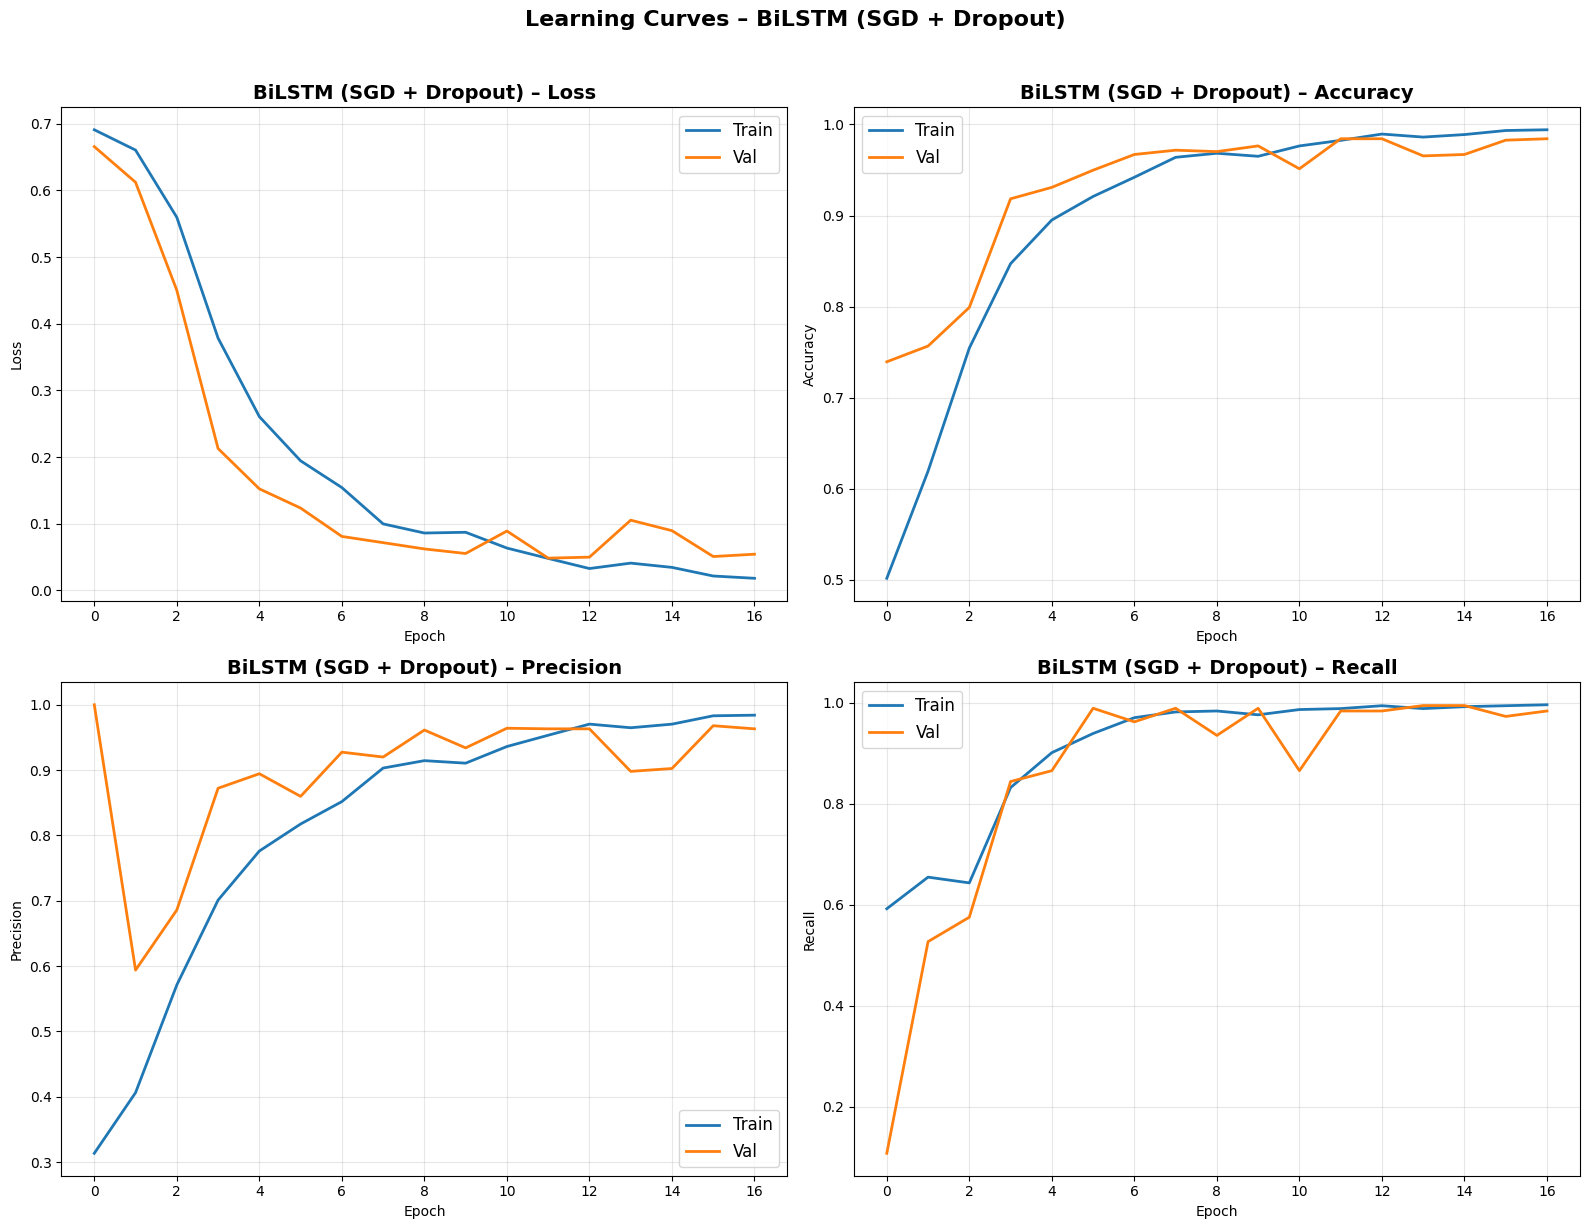


📊 ĐÁNH GIÁ BiLSTM (SGD) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9924    0.9811    0.9867       530
    Spam (1)     0.9556    0.9817    0.9685       219

    accuracy                         0.9813       749
   macro avg     0.9740    0.9814    0.9776       749
weighted avg     0.9816    0.9813    0.9814       749

📌 Accuracy : 0.9813
📌 Precision: 0.9556
📌 Recall   : 0.9817  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9685


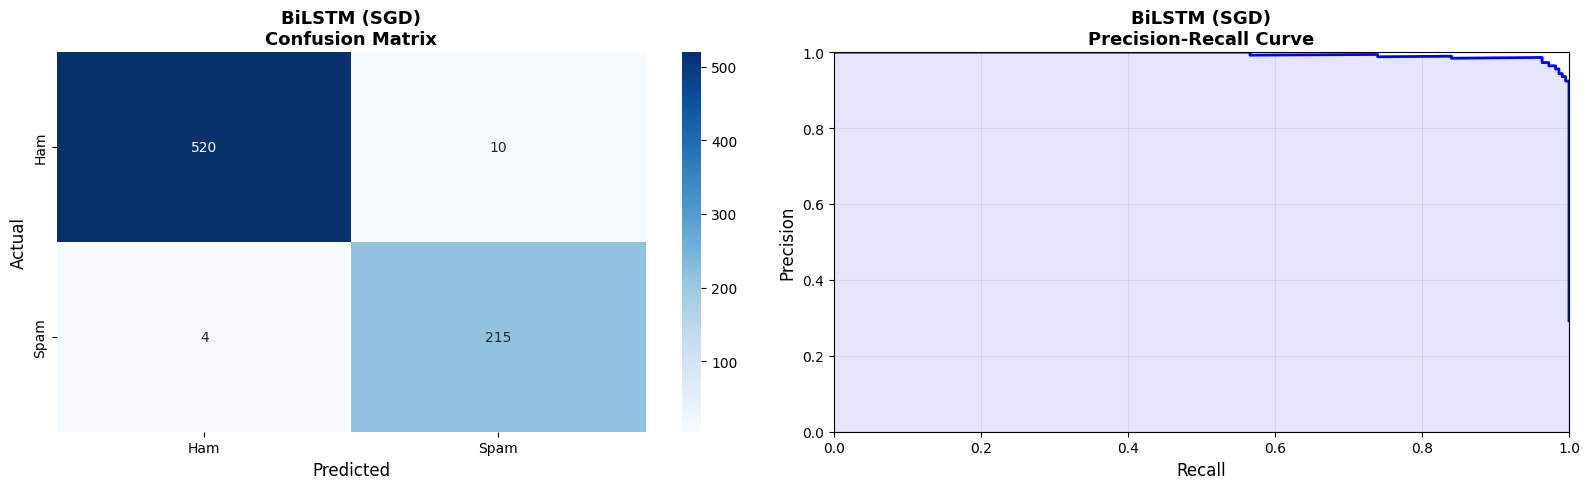

In [ ]:
# ============================================================
# PHẦN 8: THÍ NGHIỆM 1 – BiLSTM VỚI SGD
# ============================================================

print("=" * 60)
print("🔬 THÍ NGHIỆM: BiLSTM với SGD Optimizer")
print("=" * 60)

model_bilstm_sgd = build_bilstm_model(optimizer_name='sgd', dropout_rate=0.5)

BILSTM_SGD_PATH = os.path.join(SAVE_DIR, 'bilstm_sgd.keras')
callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_SGD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bilstm_sgd = model_bilstm_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_sgd, verbose=1
)

plot_learning_curves(history_bilstm_sgd, 'BiLSTM (SGD + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm_sgd.png')
results_bilstm_sgd = evaluate_model(model_bilstm_sgd, X_test, y_test, 'BiLSTM (SGD)',
                                     save_path=f'{SAVE_DIR}/eval_bilstm_sgd.png')

🔬 THÍ NGHIỆM: BiLSTM với Weight Decay (thay vì Dropout)
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8257 - loss: 0.4788 - precision: 0.6705 - recall: 0.7322
Epoch 1: val_loss improved from None to 0.07006, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_weight_decay.keras

Epoch 1: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_weight_decay.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9026 - loss: 0.2783 - precision: 0.7997 - recall: 0.8899 - val_accuracy: 0.9749 - val_loss: 0.0701 - val_precision: 0.9427 - val_recall: 0.9731 - learning_rate: 0.0010
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9811 - loss: 0.0517 - precision: 0.9519 - recall: 0.9875
Epoch 2: val_loss improved from 0.07006 to 0.02761, saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_weight_decay.keras

Epoch 2: finished saving model to /content/drive/MyDrive/email_spam_bertmoe/bilstm_weight_decay.keras
1

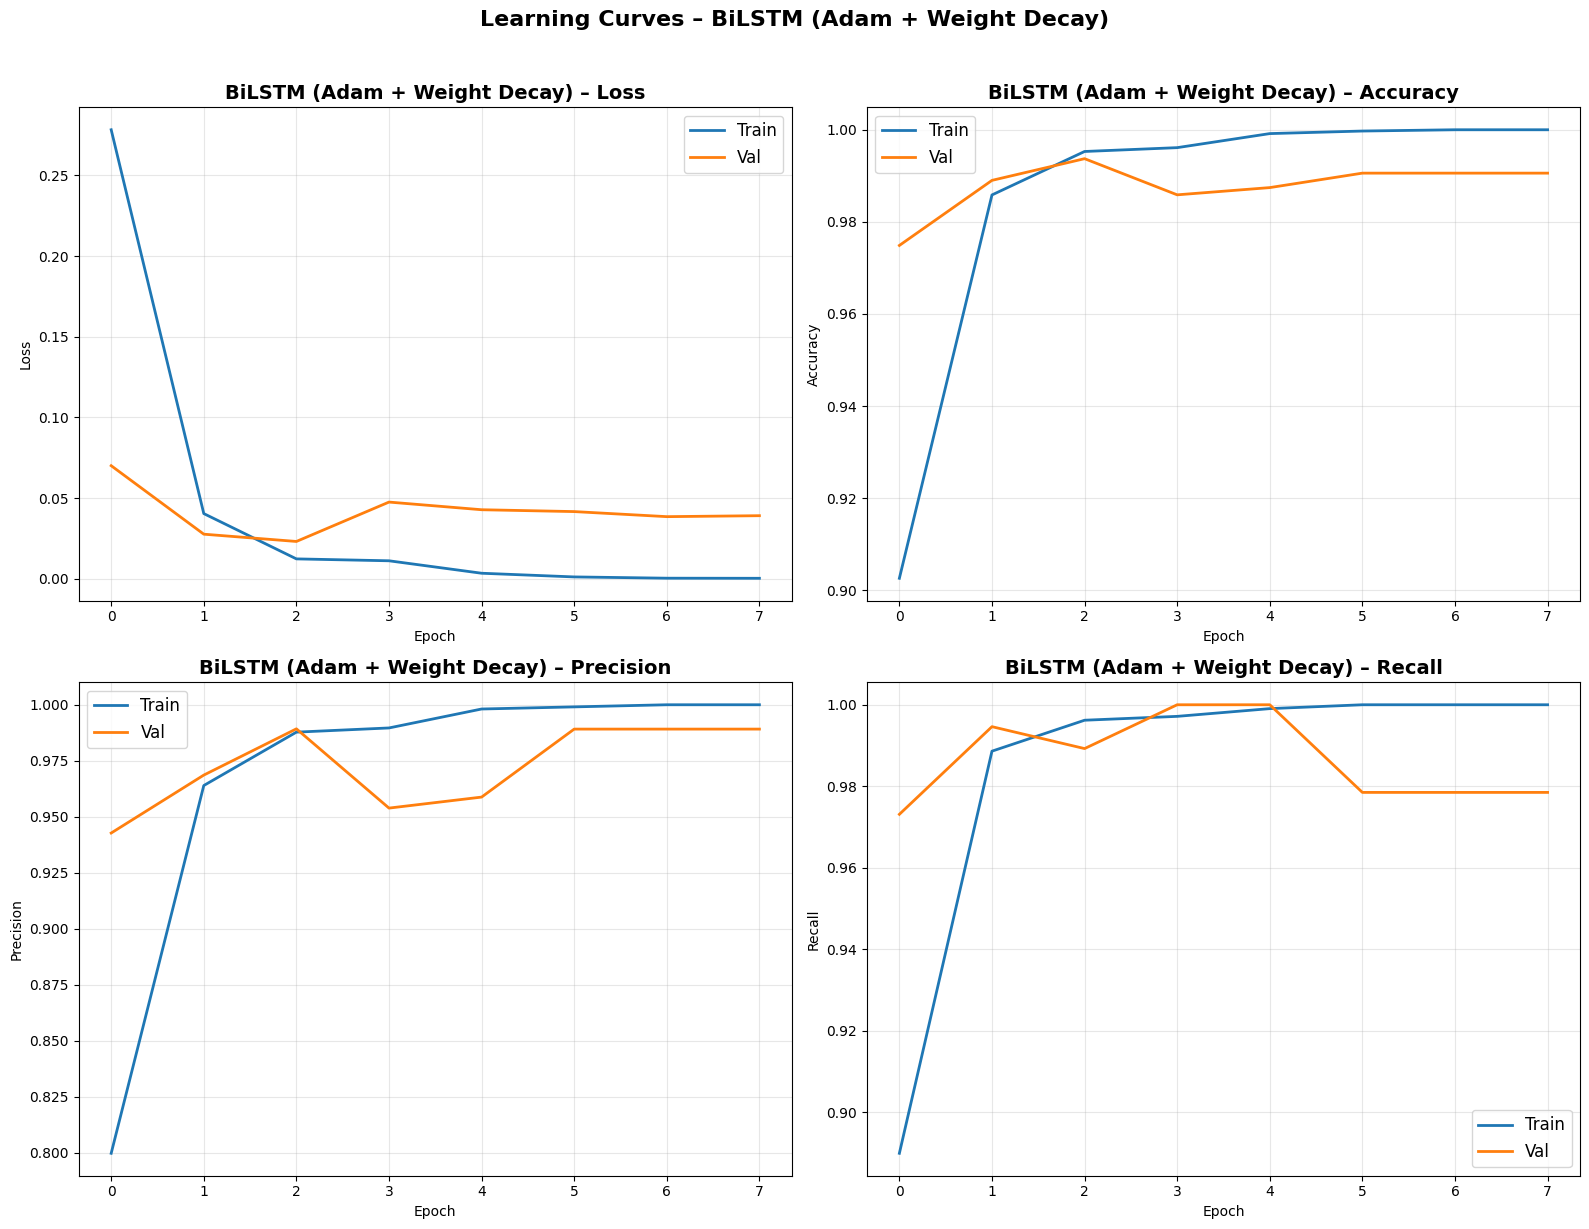


📊 ĐÁNH GIÁ BiLSTM (Weight Decay) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9924    0.9868    0.9896       530
    Spam (1)     0.9685    0.9817    0.9751       219

    accuracy                         0.9853       749
   macro avg     0.9804    0.9843    0.9823       749
weighted avg     0.9854    0.9853    0.9853       749

📌 Accuracy : 0.9853
📌 Precision: 0.9685
📌 Recall   : 0.9817  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9751


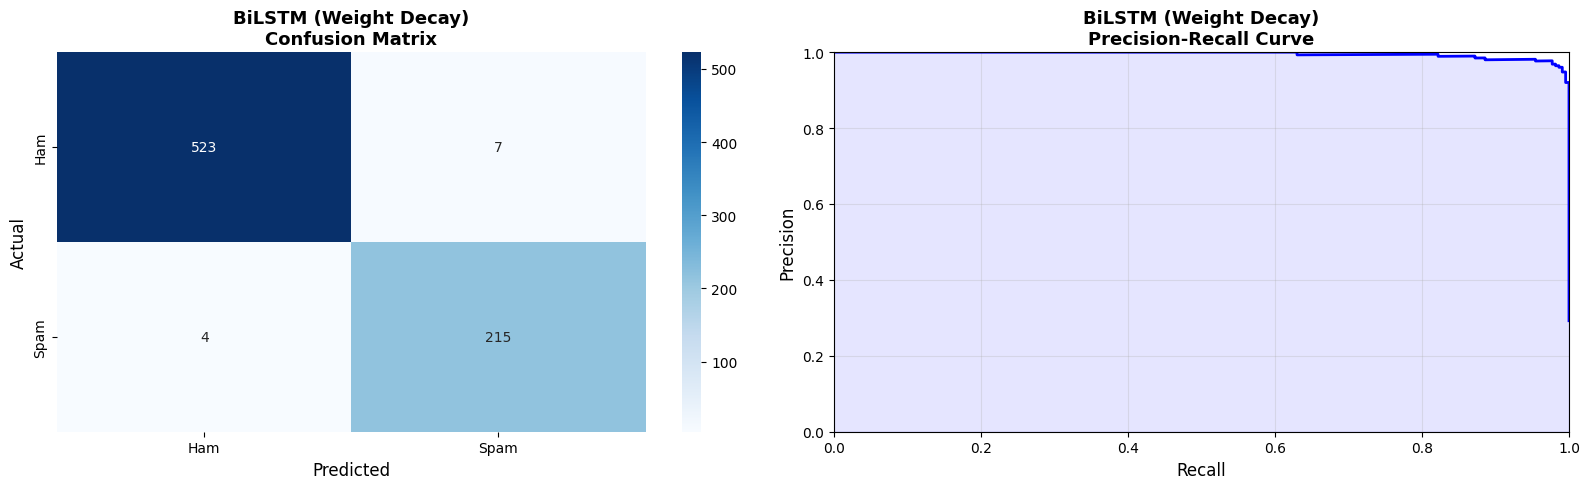

In [ ]:
# ============================================================
# PHẦN 9: THÍ NGHIỆM 2 – BiLSTM VỚI WEIGHT DECAY
# ============================================================

print("=" * 60)
print("🔬 THÍ NGHIỆM: BiLSTM với Weight Decay (thay vì Dropout)")
print("=" * 60)

model_bilstm_wd = build_bilstm_model(optimizer_name='adam', dropout_rate=0.0)

BILSTM_WD_PATH = os.path.join(SAVE_DIR, 'bilstm_weight_decay.keras')
callbacks_wd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_WD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bilstm_wd = model_bilstm_wd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_wd, verbose=1
)

plot_learning_curves(history_bilstm_wd, 'BiLSTM (Adam + Weight Decay)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm_wd.png')
results_bilstm_wd = evaluate_model(model_bilstm_wd, X_test, y_test, 'BiLSTM (Weight Decay)',
                                    save_path=f'{SAVE_DIR}/eval_bilstm_wd.png')

📊 BẢNG SO SÁNH CÁC THÍ NGHIỆM – MÔ HÌNH 1 (BiLSTM)
                     Mô hình          Optimizer    Regularization Accuracy Precision Recall (Spam) F1-Score
     BiLSTM (Adam + Dropout)               Adam       Dropout=0.5   0.9880    0.9688        0.9909   0.9797
      BiLSTM (SGD + Dropout) SGD (momentum=0.9)       Dropout=0.5   0.9813    0.9556        0.9817   0.9685
BiLSTM (Adam + Weight Decay)    AdamW (wd=1e-4) Weight Decay=1e-4   0.9853    0.9685        0.9817   0.9751


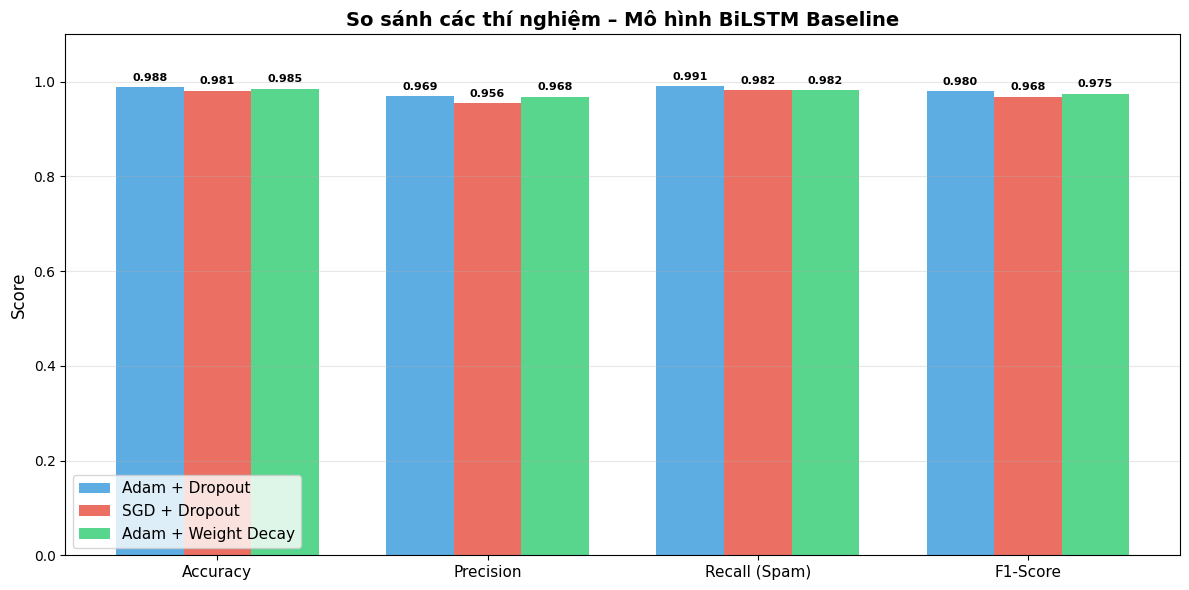

In [ ]:
# ============================================================
# PHẦN 10: BẢNG SO SÁNH CÁC THÍ NGHIỆM – MÔ HÌNH 1 (BiLSTM)
# ============================================================

print("=" * 60)
print("📊 BẢNG SO SÁNH CÁC THÍ NGHIỆM – MÔ HÌNH 1 (BiLSTM)")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Mô hình': ['BiLSTM (Adam + Dropout)', 'BiLSTM (SGD + Dropout)', 'BiLSTM (Adam + Weight Decay)'],
    'Optimizer': ['Adam', 'SGD (momentum=0.9)', 'AdamW (wd=1e-4)'],
    'Regularization': ['Dropout=0.5', 'Dropout=0.5', 'Weight Decay=1e-4'],
    'Accuracy': [results_bilstm['accuracy'], results_bilstm_sgd['accuracy'], results_bilstm_wd['accuracy']],
    'Precision': [results_bilstm['precision'], results_bilstm_sgd['precision'], results_bilstm_wd['precision']],
    'Recall (Spam)': [results_bilstm['recall'], results_bilstm_sgd['recall'], results_bilstm_wd['recall']],
    'F1-Score': [results_bilstm['f1'], results_bilstm_sgd['f1'], results_bilstm_wd['f1']],
})

for col in ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f'{x:.4f}')
print(comparison_df.to_string(index=False))

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
width = 0.25
metrics = ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']
values_adam = [results_bilstm['accuracy'], results_bilstm['precision'],
               results_bilstm['recall'], results_bilstm['f1']]
values_sgd = [results_bilstm_sgd['accuracy'], results_bilstm_sgd['precision'],
              results_bilstm_sgd['recall'], results_bilstm_sgd['f1']]
values_wd = [results_bilstm_wd['accuracy'], results_bilstm_wd['precision'],
             results_bilstm_wd['recall'], results_bilstm_wd['f1']]

bars1 = ax.bar(x - width, values_adam, width, label='Adam + Dropout', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, values_sgd, width, label='SGD + Dropout', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width, values_wd, width, label='Adam + Weight Decay', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('So sánh các thí nghiệm – Mô hình BiLSTM Baseline', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_experiments_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## MÔ HÌNH 2 – NÂNG CAO: BERT MoE
### `AntiSpamInstitute/spam-detector-bert-MoE-v2.2`
**Mixture of Experts (MoE):** Kiến trúc BERT kết hợp nhiều expert networks,
mỗi expert chuyên biệt xử lý một loại pattern khác nhau trong email.
So với BiLSTM baseline, BERT MoE mang lại:
- **Transfer learning** từ dữ liệu pre-train khổng lồ
- **Attention mechanism** toàn cục (không chỉ local context như LSTM)
- **MoE routing** cho phép model chuyên biệt hóa theo loại email

CHUAN BI DU LIEU CHO BERT MoE

Dang tai BERT tokenizer tu AntiSpamInstitute/spam-detector-bert-MoE-v2.2 ...
Tokenizer san sang! Vocab size: 30522

Model goc num_labels = 2
Label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}
Model da duoc pre-train cho spam detection!
KHONG can ignore_mismatched_sizes=True

Tap du lieu BERT MoE:
   Train     : 3494 mau
   Validation: 747 mau
   Test      : 749 mau

DataLoaders san sang!
   Train batches : 437
   Val batches   : 94
   Test batches  : 94

Class weights: Ham(0)=0.7067, Spam(1)=1.7094
MAX_LEN = 512 (tang tu 256 -> 512)
EPOCHS  = 10 (tang tu 5 -> 10)
BATCH   = 8 (giam do MAX_LEN tang)

TEST ZERO-SHOT: Model goc chua fine-tune


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}

Accuracy (label binh thuong)  : 0.3591
Accuracy (label dao nguoc)    : 0.6409

PHAT HIEN: Label mapping bi nguoc!
   Model goc: 0=LABEL_0, 1=LABEL_1
   Dataset  : 0=Ham, 1=Spam
   -> Can dao nguoc labels khi train

Classification Report (sau khi dao label):
              precision    recall  f1-score   support

     Ham (0)     0.8014    0.6547    0.7207       530
    Spam (1)     0.4209    0.6073    0.4972       219

    accuracy                         0.6409       749
   macro avg     0.6111    0.6310    0.6089       749
weighted avg     0.6901    0.6409    0.6553       749



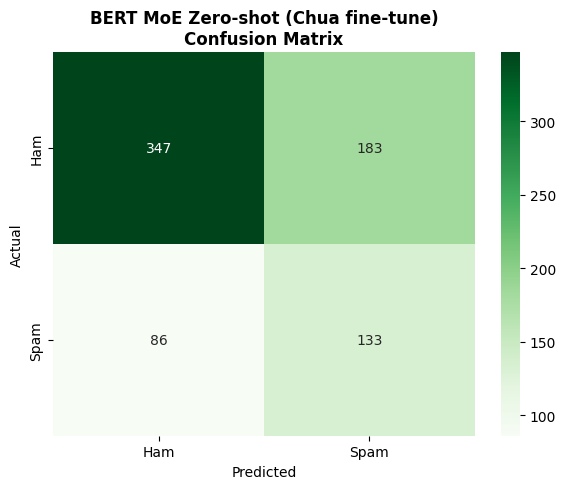


ZERO-SHOT: Acc=0.6409 Prec=0.4209 Rec=0.6073 F1=0.4972

Zero-shot test hoan tat! Bay gio se fine-tune de cai thien them.


In [ ]:
# ============================================================
# PHAN 11: CHUAN BI DU LIEU CHO BERT MoE
# ============================================================

print("=" * 60)
print("CHUAN BI DU LIEU CHO BERT MoE")
print("=" * 60)

BERT_MODEL_NAME = "AntiSpamInstitute/spam-detector-bert-MoE-v2.2"
BERT_MAX_LEN    = 512    # FIX: Tang len 512 (BERT ho tro toi da 512 tokens)
BERT_BATCH_SIZE = 8      # FIX: Giam batch size vi MAX_LEN tang
BERT_EPOCHS     = 10     # FIX: Tang epochs (5 la chua du cho dataset nho)

# Load BERT tokenizer
print(f"\nDang tai BERT tokenizer tu {BERT_MODEL_NAME} ...")
bert_tokenizer = HFTokenizer.from_pretrained(BERT_MODEL_NAME)
print(f"Tokenizer san sang! Vocab size: {bert_tokenizer.vocab_size}")

# FIX: Kiem tra model goc co bao nhieu labels
from transformers import AutoConfig
bert_config = AutoConfig.from_pretrained(BERT_MODEL_NAME)
print(f"\nModel goc num_labels = {bert_config.num_labels}")
print(f"Label mapping: {bert_config.id2label}")
print(f"Model da duoc pre-train cho spam detection!")
print(f"KHONG can ignore_mismatched_sizes=True")

# Custom PyTorch Dataset
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Chia tap du lieu
texts_all  = df_clean['text'].values
labels_all = df_clean['label_num'].values

texts_train_full, texts_test, y_train_full_b, y_test_b = train_test_split(
    texts_all, labels_all, test_size=0.15, random_state=SEED, stratify=labels_all)
texts_train, texts_val, y_train_b, y_val_b = train_test_split(
    texts_train_full, y_train_full_b, test_size=0.176, random_state=SEED, stratify=y_train_full_b)

print(f"\nTap du lieu BERT MoE:")
print(f"   Train     : {len(texts_train)} mau")
print(f"   Validation: {len(texts_val)} mau")
print(f"   Test      : {len(texts_test)} mau")

# Tao DataLoaders
train_dataset = EmailDataset(texts_train, y_train_b, bert_tokenizer, BERT_MAX_LEN)
val_dataset   = EmailDataset(texts_val,   y_val_b,   bert_tokenizer, BERT_MAX_LEN)
test_dataset  = EmailDataset(texts_test,  y_test_b,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataLoaders san sang!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# XU LY MAT CAN BANG DU LIEU
bert_class_weights = compute_class_weight('balanced', classes=np.unique(y_train_b), y=y_train_b)
bert_class_weight_tensor = torch.tensor(bert_class_weights, dtype=torch.float32).to(DEVICE)
weighted_loss_fn = torch.nn.CrossEntropyLoss(weight=bert_class_weight_tensor)

print(f"\nClass weights: Ham(0)={bert_class_weights[0]:.4f}, Spam(1)={bert_class_weights[1]:.4f}")
print(f"MAX_LEN = {BERT_MAX_LEN} (tang tu 256 -> 512)")
print(f"EPOCHS  = {BERT_EPOCHS} (tang tu 5 -> 10)")
print(f"BATCH   = {BERT_BATCH_SIZE} (giam do MAX_LEN tang)")

# ============================================================
# TEST ZERO-SHOT: Kiem tra model GOC (chua fine-tune)
# ============================================================
print(f"\n{'='*60}")
print("TEST ZERO-SHOT: Model goc chua fine-tune")
print("=" * 60)

bert_model_zeroshot = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME  # KHONG dung ignore_mismatched_sizes
).to(DEVICE)
bert_model_zeroshot.eval()

print(f"id2label: {bert_model_zeroshot.config.id2label}")
print(f"label2id: {bert_model_zeroshot.config.label2id}")

# Test tren toan bo test set
all_preds_zs, all_labels_zs = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = bert_model_zeroshot(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds_zs.extend(preds)
        all_labels_zs.extend(batch['labels'].numpy())

all_preds_zs = np.array(all_preds_zs)
all_labels_zs = np.array(all_labels_zs)

# Kiem tra label mapping co bi nguoc khong
acc_normal  = accuracy_score(all_labels_zs, all_preds_zs)
acc_flipped = accuracy_score(all_labels_zs, 1 - all_preds_zs)

print(f"\nAccuracy (label binh thuong)  : {acc_normal:.4f}")
print(f"Accuracy (label dao nguoc)    : {acc_flipped:.4f}")

if acc_flipped > acc_normal:
    FLIP_LABELS = True
    print(f"\nPHAT HIEN: Label mapping bi nguoc!")
    print(f"   Model goc: 0={bert_model_zeroshot.config.id2label[0]}, 1={bert_model_zeroshot.config.id2label[1]}")
    print(f"   Dataset  : 0=Ham, 1=Spam")
    print(f"   -> Can dao nguoc labels khi train")
    print(f"\nClassification Report (sau khi dao label):")
    print(classification_report(all_labels_zs, 1 - all_preds_zs,
                                target_names=['Ham (0)', 'Spam (1)'], digits=4))
else:
    FLIP_LABELS = False
    print(f"\nLabel mapping chinh xac!")
    print(f"\nClassification Report (zero-shot):")
    print(classification_report(all_labels_zs, all_preds_zs,
                                target_names=['Ham (0)', 'Spam (1)'], digits=4))

# Confusion matrix zero-shot
y_pred_zs_final = (1 - all_preds_zs) if FLIP_LABELS else all_preds_zs
cm_zs = confusion_matrix(all_labels_zs, y_pred_zs_final)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax.set_title('BERT MoE Zero-shot (Chua fine-tune)\nConfusion Matrix', fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eval_bert_zeroshot.png', dpi=150, bbox_inches='tight')
plt.show()

zs_acc = accuracy_score(all_labels_zs, y_pred_zs_final)
zs_prec = precision_score(all_labels_zs, y_pred_zs_final, zero_division=0)
zs_rec = recall_score(all_labels_zs, y_pred_zs_final, zero_division=0)
zs_f1 = f1_score(all_labels_zs, y_pred_zs_final, zero_division=0)
results_bert_zeroshot = {'accuracy': zs_acc, 'precision': zs_prec, 'recall': zs_rec, 'f1': zs_f1}
print(f"\nZERO-SHOT: Acc={zs_acc:.4f} Prec={zs_prec:.4f} Rec={zs_rec:.4f} F1={zs_f1:.4f}")

del bert_model_zeroshot
torch.cuda.empty_cache()
print("\nZero-shot test hoan tat! Bay gio se fine-tune de cai thien them.")

In [ ]:
# ============================================================
# PHAN 12: HAM TRAINING & DANH GIA CHO BERT MoE (PyTorch)
# Ho tro: Weighted Loss + Label Flipping
# ============================================================

def train_one_epoch(model, loader, optimizer, scheduler, device, loss_fn=None, flip_labels=False):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        # Neu label mapping nguoc, dao labels khi tinh loss
        train_labels = (1 - labels) if flip_labels else labels

        if loss_fn is not None:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, train_labels)
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=train_labels)
            loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        raw_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds = (1 - raw_preds) if flip_labels else raw_preds
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, prec, rec


def evaluate_one_epoch(model, loader, device, loss_fn=None, flip_labels=False):
    model.eval()
    total_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            train_labels = (1 - labels) if flip_labels else labels

            if loss_fn is not None:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, train_labels)
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=train_labels)
                loss = outputs.loss

            total_loss += loss.item()

            all_probs_batch = torch.softmax(outputs.logits, dim=1)
            # Xac suat spam: neu flip thi lay cot 0 (thay vi cot 1)
            if flip_labels:
                probs = all_probs_batch[:, 0].cpu().numpy()
            else:
                probs = all_probs_batch[:, 1].cpu().numpy()

            preds = (probs >= 0.5).astype(int)
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, prec, rec, f1, np.array(all_probs), np.array(all_labels)


def train_bert_full(model, train_loader, val_loader, optimizer, scheduler,
                    model_name, save_path, device, num_epochs=5, patience=3,
                    loss_fn=None, flip_labels=False):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [],  'val_acc': [],
        'train_prec': [], 'val_prec': [],
        'train_rec': [],  'val_rec': [],
        'val_f1': []
    }
    best_val_loss = float('inf')
    patience_count = 0

    loss_name = "Weighted CE" if loss_fn is not None else "Default CE"
    print(f"Loss: {loss_name} | Flip labels: {flip_labels}")

    for epoch in range(num_epochs):
        tr_loss, tr_acc, tr_prec, tr_rec = train_one_epoch(
            model, train_loader, optimizer, scheduler, device,
            loss_fn=loss_fn, flip_labels=flip_labels)
        vl_loss, vl_acc, vl_prec, vl_rec, vl_f1, _, _ = evaluate_one_epoch(
            model, val_loader, device, loss_fn=loss_fn, flip_labels=flip_labels)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_prec'].append(tr_prec)
        history['val_prec'].append(vl_prec)
        history['train_rec'].append(tr_rec)
        history['val_rec'].append(vl_rec)
        history['val_f1'].append(vl_f1)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} "
              f"Prec: {vl_prec:.4f} Rec: {vl_rec:.4f} F1: {vl_f1:.4f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_count = 0
            torch.save(model.state_dict(), save_path)
            print(f"  Best model saved -> {save_path}")
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  EarlyStopping tai epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    return history


def plot_bert_learning_curves(history, model_name, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0,0].plot(history['train_loss'], label='Train', lw=2)
    axes[0,0].plot(history['val_loss'],   label='Val',   lw=2)
    axes[0,0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
    axes[0,1].plot(history['train_acc'], label='Train', lw=2)
    axes[0,1].plot(history['val_acc'],   label='Val',   lw=2)
    axes[0,1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
    axes[1,0].plot(history['train_prec'], label='Train', lw=2)
    axes[1,0].plot(history['val_prec'],   label='Val',   lw=2)
    axes[1,0].set_title(f'{model_name} - Precision', fontsize=14, fontweight='bold')
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
    axes[1,1].plot(history['train_rec'], label='Train', lw=2)
    axes[1,1].plot(history['val_rec'],   label='Val',   lw=2)
    axes[1,1].set_title(f'{model_name} - Recall', fontsize=14, fontweight='bold')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)
    plt.suptitle(f'Learning Curves - {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_bert_test(model, test_loader, model_name, device, save_path=None,
                       loss_fn=None, flip_labels=False):
    _, acc, prec, rec, f1, y_probs, y_true = evaluate_one_epoch(
        model, test_loader, device, loss_fn=loss_fn, flip_labels=flip_labels)
    y_pred = (y_probs >= 0.5).astype(int)

    print(f"\n{'='*60}")
    print(f"DANH GIA {model_name} TREN TAP TEST")
    print(f"{'='*60}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Ham (0)', 'Spam (1)'], digits=4))
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    print(f"\nFalse Positives (Ham->Spam) : {fp}")
    print(f"False Negatives (Spam->Ham) : {fn}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
    pr_vals, rc_vals, _ = precision_recall_curve(y_true, y_probs)
    axes[1].plot(rc_vals, pr_vals, lw=2, color='red')
    axes[1].fill_between(rc_vals, pr_vals, alpha=0.1, color='red')
    axes[1].set_title(f'{model_name}\nPrecision-Recall Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].grid(True, alpha=0.3); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1])
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_probs': y_probs, 'y_true': y_true}

print("Tat ca ham training/evaluation da san sang!")
print("Ho tro: Weighted Loss + Label Flipping + Patience=3")

Tat ca ham training/evaluation da san sang!
Ho tro: Weighted Loss + Label Flipping + Patience=3


MO HINH 2: BERT MoE - Full Fine-tuning (AdamW + Weighted Loss)


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]


Tong tham so BERT MoE   : 4,386,178
Tham so trainable       : 4,386,178
So sanh BiLSTM Baseline : 3,949,185 tham so
BERT MoE lon hon        : 1x
id2label                : {0: 'LABEL_0', 1: 'LABEL_1'}

Chien luoc  : Full Fine-tuning (giu nguyen pre-trained head)
Optimizer   : AdamW (lr=2e-05, weight_decay=0.01)
Scheduler   : Linear warmup (437 steps) -> linear decay
Loss        : Weighted CrossEntropyLoss
Epochs      : 10
Batch size  : 8
Max length  : 512

Bat dau huan luyen BERT MoE (AdamW + Weighted Loss)...
Loss: Weighted CE | Flip labels: True
Epoch 1/10 | Train Loss: 0.4459 Acc: 0.7444 | Val Loss: 0.2681 Acc: 0.8246 Prec: 0.8718 Rec: 0.4679 F1: 0.6090
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_adamw.pt
Epoch 2/10 | Train Loss: 0.1886 Acc: 0.8998 | Val Loss: 0.1796 Acc: 0.8876 Prec: 0.9718 Rec: 0.6330 F1: 0.7667
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_adamw.pt
Epoch 3/10 | Train Loss: 0.1041 Acc: 0.9519 | Val Loss: 0.13

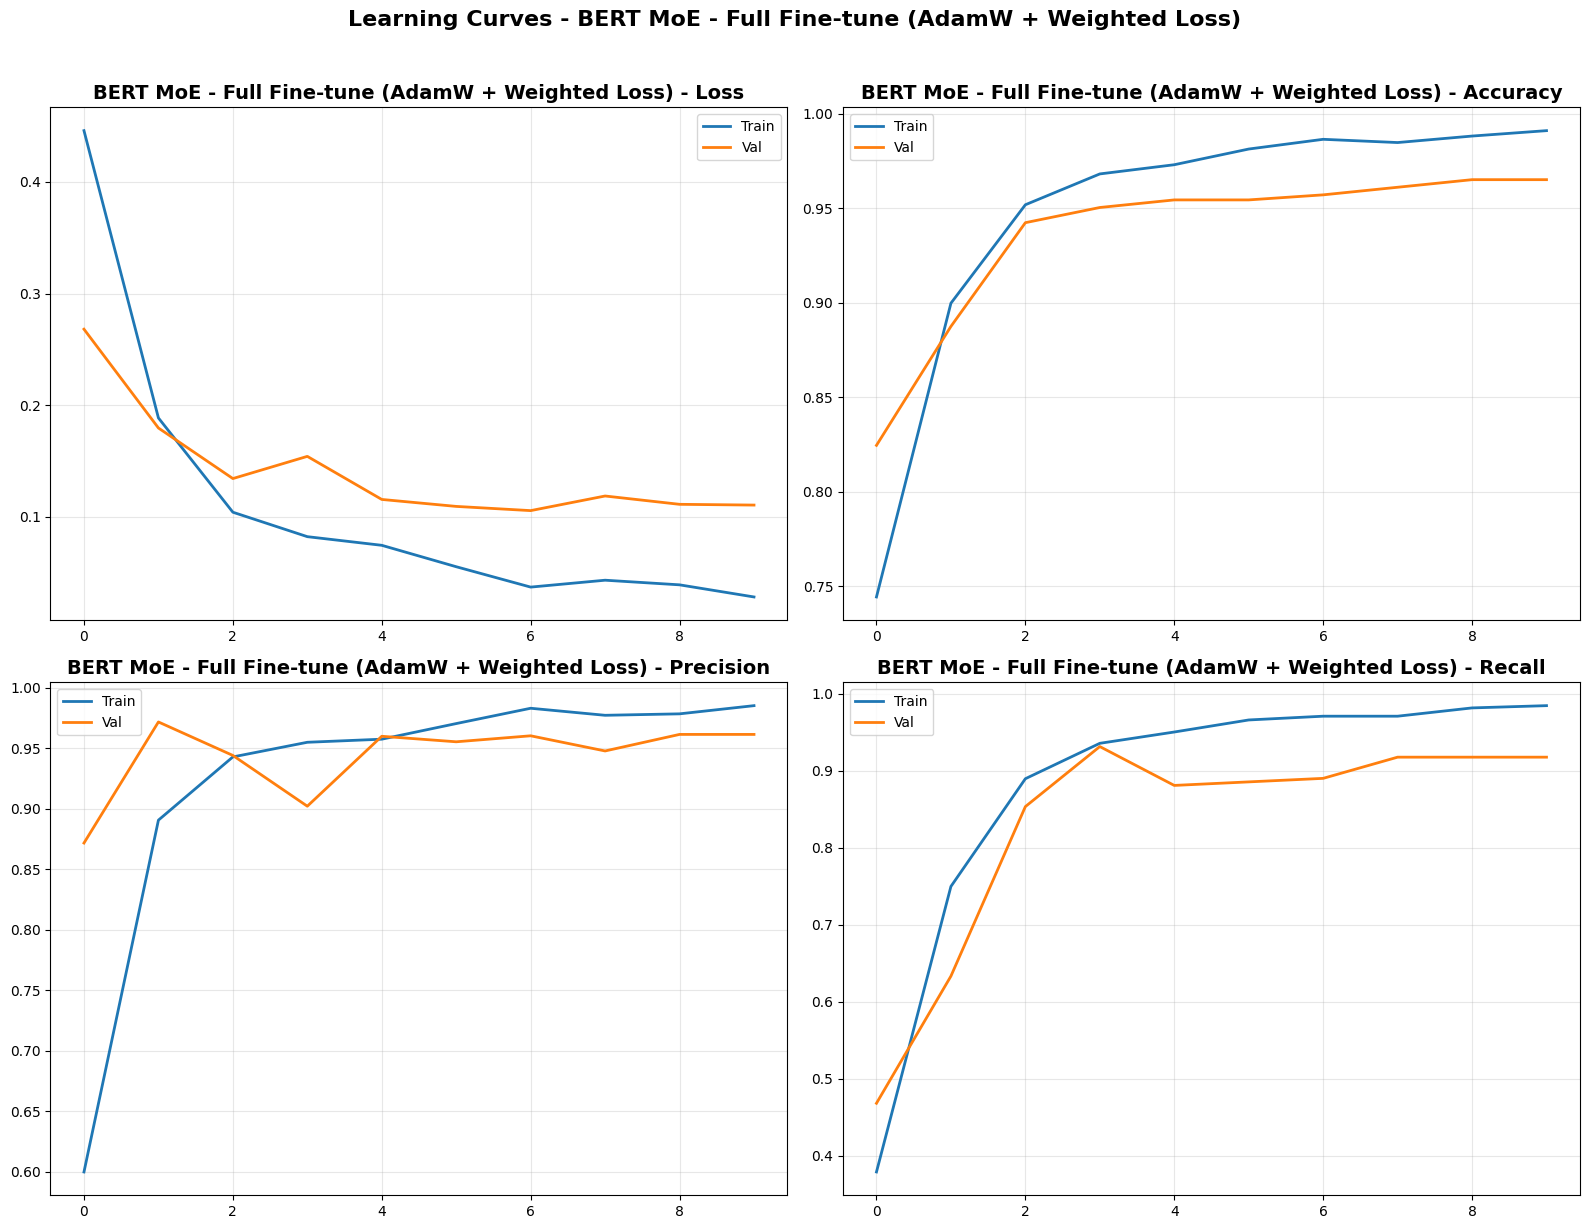


DANH GIA BERT MoE (AdamW + Weighted Loss) TREN TAP TEST

Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9758    0.9887    0.9822       530
    Spam (1)     0.9717    0.9406    0.9559       219

    accuracy                         0.9746       749
   macro avg     0.9737    0.9647    0.9691       749
weighted avg     0.9746    0.9746    0.9745       749

Accuracy : 0.9746
Precision: 0.9717
Recall   : 0.9406
F1-Score : 0.9559

False Positives (Ham->Spam) : 6
False Negatives (Spam->Ham) : 13


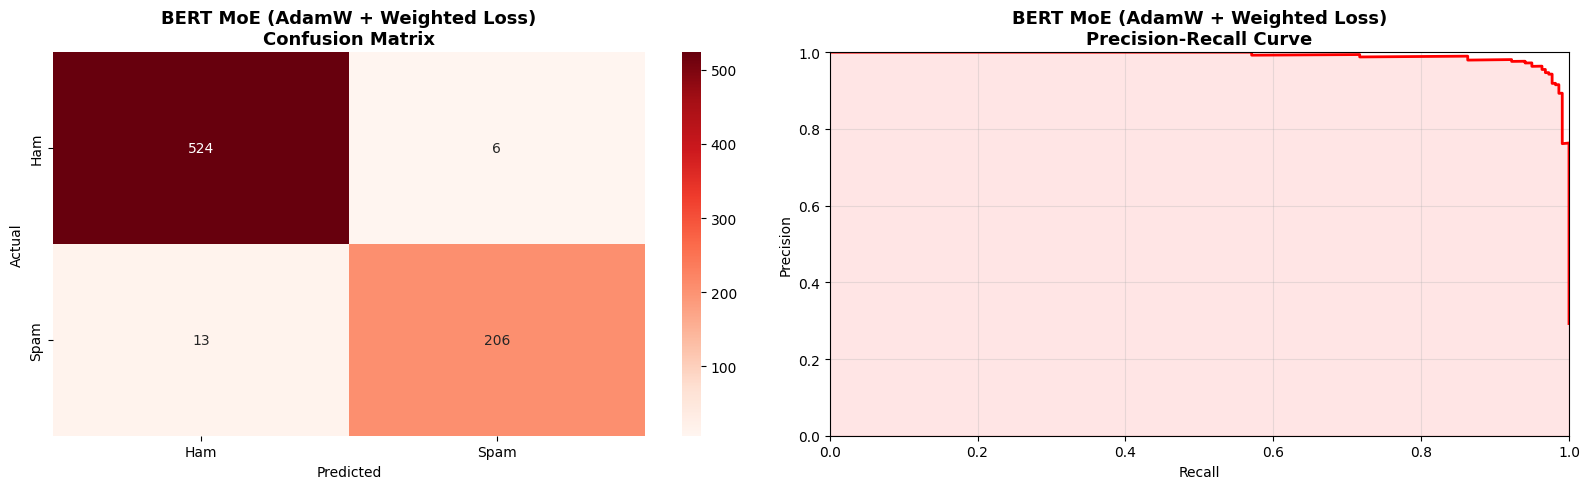

In [ ]:
# ============================================================
# PHAN 13: MO HINH 2 - BERT MoE: FULL FINE-TUNE (AdamW)
# KHONG dung ignore_mismatched_sizes -> giu nguyen pre-trained head
# ============================================================

print("=" * 60)
print("MO HINH 2: BERT MoE - Full Fine-tuning (AdamW + Weighted Loss)")
print("=" * 60)

# FIX: Load model KHONG reset classifier head
bert_model_adamw = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME  # BO ignore_mismatched_sizes=True va num_labels=2
).to(DEVICE)

total_params_bert = sum(p.numel() for p in bert_model_adamw.parameters())
trainable_params_bert = sum(p.numel() for p in bert_model_adamw.parameters() if p.requires_grad)
print(f"\nTong tham so BERT MoE   : {total_params_bert:,}")
print(f"Tham so trainable       : {trainable_params_bert:,}")
print(f"So sanh BiLSTM Baseline : {total_params:,} tham so")
print(f"BERT MoE lon hon        : {total_params_bert/total_params:.0f}x")
print(f"id2label                : {bert_model_adamw.config.id2label}")

# Optimizer & Scheduler
LR_ADAMW     = 2e-5
WARMUP_RATIO = 0.1

total_steps  = len(train_loader) * BERT_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer_adamw = torch.optim.AdamW(bert_model_adamw.parameters(),
                                     lr=LR_ADAMW, weight_decay=0.01)
scheduler_adamw = get_linear_schedule_with_warmup(
    optimizer_adamw, warmup_steps, total_steps)

print(f"\nChien luoc  : Full Fine-tuning (giu nguyen pre-trained head)")
print(f"Optimizer   : AdamW (lr={LR_ADAMW}, weight_decay=0.01)")
print(f"Scheduler   : Linear warmup ({warmup_steps} steps) -> linear decay")
print(f"Loss        : Weighted CrossEntropyLoss")
print(f"Epochs      : {BERT_EPOCHS}")
print(f"Batch size  : {BERT_BATCH_SIZE}")
print(f"Max length  : {BERT_MAX_LEN}")

# Huan luyen - TRUYEN weighted_loss_fn
BERT_ADAMW_PATH = os.path.join(SAVE_DIR, 'bert_moe_adamw.pt')

print(f"\nBat dau huan luyen BERT MoE (AdamW + Weighted Loss)...")
history_bert_adamw = train_bert_full(
    bert_model_adamw, train_loader, val_loader,
    optimizer_adamw, scheduler_adamw,
    'BERT MoE (AdamW)', BERT_ADAMW_PATH,
    DEVICE, num_epochs=BERT_EPOCHS, patience=3,
    loss_fn=weighted_loss_fn, flip_labels=FLIP_LABELS
)

plot_bert_learning_curves(history_bert_adamw, 'BERT MoE - Full Fine-tune (AdamW + Weighted Loss)',
                          save_path=f'{SAVE_DIR}/learning_curves_bert_adamw.png')

results_bert_adamw = evaluate_bert_test(
    bert_model_adamw, test_loader, 'BERT MoE (AdamW + Weighted Loss)', DEVICE,
    save_path=f'{SAVE_DIR}/eval_bert_adamw.png', loss_fn=weighted_loss_fn,
    flip_labels=FLIP_LABELS)

THI NGHIEM: BERT MoE voi SGD Optimizer + Weighted Loss


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

Optimizer : SGD (lr=0.0005, momentum=0.9)
Scheduler : StepLR (giam 50% moi epoch)
Loss      : Weighted CrossEntropyLoss
Loss: Weighted CE | Flip labels: True
Epoch 1/10 | Train Loss: 0.3693 Acc: 0.7622 | Val Loss: 0.3069 Acc: 0.7805 Prec: 0.8462 Rec: 0.3028 F1: 0.4459
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_sgd.pt
Epoch 2/10 | Train Loss: 0.2775 Acc: 0.8274 | Val Loss: 0.2607 Acc: 0.8139 Prec: 0.8990 Rec: 0.4083 F1: 0.5615
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_sgd.pt
Epoch 3/10 | Train Loss: 0.2461 Acc: 0.8517 | Val Loss: 0.2379 Acc: 0.8380 Prec: 0.8943 Rec: 0.5046 F1: 0.6452
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_sgd.pt
Epoch 4/10 | Train Loss: 0.2314 Acc: 0.8600 | Val Loss: 0.2245 Acc: 0.8514 Prec: 0.9023 Rec: 0.5505 F1: 0.6838
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_sgd.pt
Epoch 5/10 | Train Loss: 0.2242 Acc: 0.8649 | Val Loss: 0.2194 Acc: 0.8514 Pre

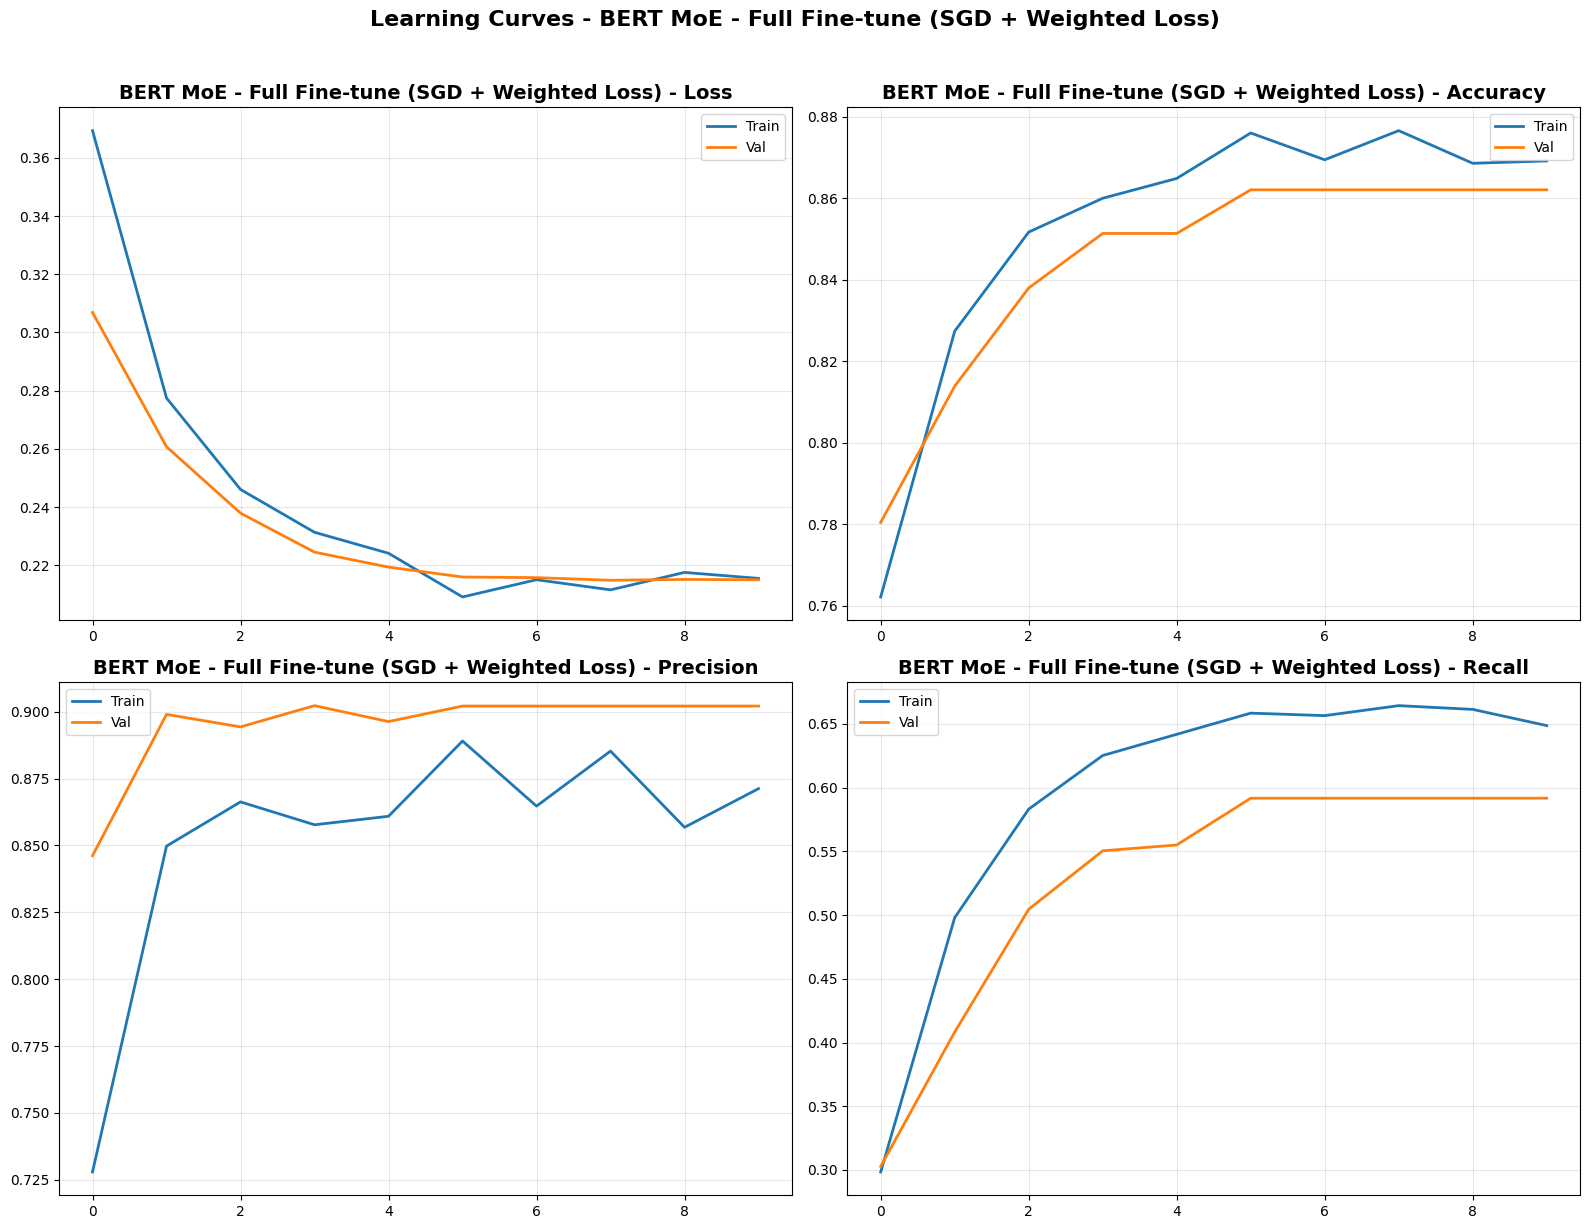


DANH GIA BERT MoE (SGD + Weighted Loss) TREN TAP TEST

Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.8607    0.9679    0.9112       530
    Spam (1)     0.8889    0.6210    0.7312       219

    accuracy                         0.8665       749
   macro avg     0.8748    0.7945    0.8212       749
weighted avg     0.8690    0.8665    0.8586       749

Accuracy : 0.8665
Precision: 0.8889
Recall   : 0.6210
F1-Score : 0.7312

False Positives (Ham->Spam) : 17
False Negatives (Spam->Ham) : 83


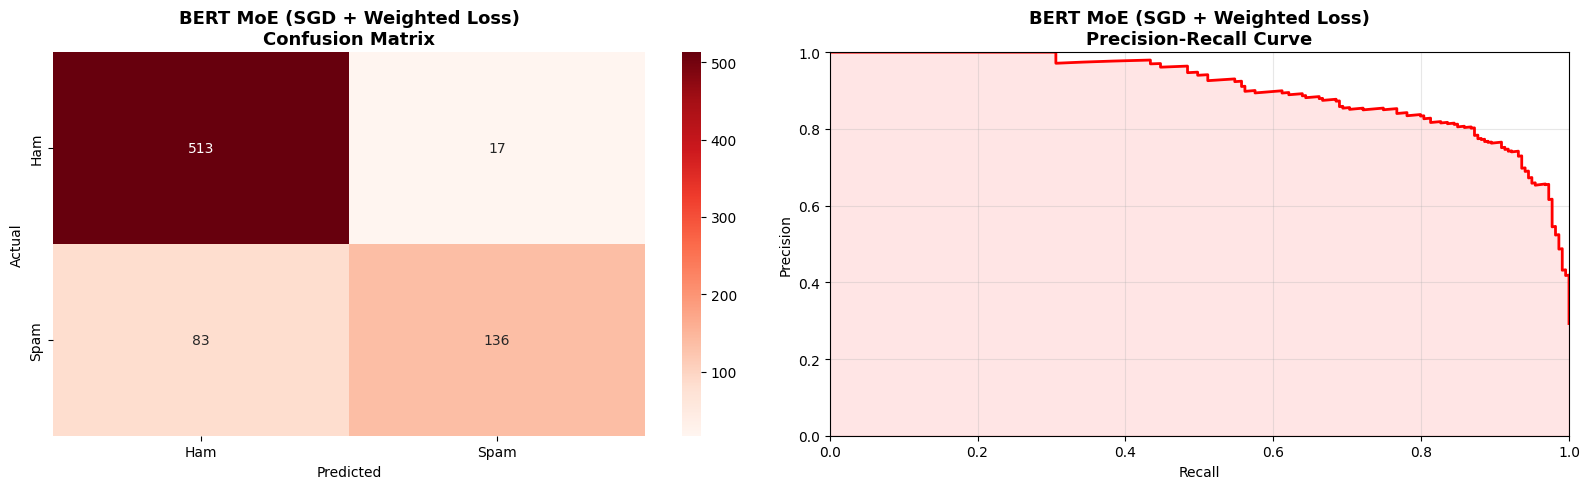

In [ ]:
# ============================================================
# PHAN 14: THI NGHIEM 1 - BERT MoE VOI SGD + WEIGHTED LOSS
# ============================================================

print("=" * 60)
print("THI NGHIEM: BERT MoE voi SGD Optimizer + Weighted Loss")
print("=" * 60)

bert_model_sgd = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME  # KHONG dung ignore_mismatched_sizes
).to(DEVICE)

LR_SGD = 5e-4  # FIX: Giam lr cho SGD (1e-3 qua cao cho fine-tune BERT)
optimizer_sgd = torch.optim.SGD(bert_model_sgd.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_sgd = torch.optim.lr_scheduler.StepLR(
    optimizer_sgd, step_size=len(train_loader), gamma=0.5)

print(f"Optimizer : SGD (lr={LR_SGD}, momentum=0.9)")
print(f"Scheduler : StepLR (giam 50% moi epoch)")
print(f"Loss      : Weighted CrossEntropyLoss")

BERT_SGD_PATH = os.path.join(SAVE_DIR, 'bert_moe_sgd.pt')
history_bert_sgd = train_bert_full(
    bert_model_sgd, train_loader, val_loader,
    optimizer_sgd, scheduler_sgd,
    'BERT MoE (SGD)', BERT_SGD_PATH,
    DEVICE, num_epochs=BERT_EPOCHS, patience=3,
    loss_fn=weighted_loss_fn, flip_labels=FLIP_LABELS
)

plot_bert_learning_curves(history_bert_sgd, 'BERT MoE - Full Fine-tune (SGD + Weighted Loss)',
                          save_path=f'{SAVE_DIR}/learning_curves_bert_sgd.png')
results_bert_sgd = evaluate_bert_test(
    bert_model_sgd, test_loader, 'BERT MoE (SGD + Weighted Loss)', DEVICE,
    save_path=f'{SAVE_DIR}/eval_bert_sgd.png', loss_fn=weighted_loss_fn,
    flip_labels=FLIP_LABELS)

THI NGHIEM: BERT MoE - Frozen BERT Encoder + Weighted Loss
Chien luoc: Dong bang toan bo BERT encoder, chi train classifier head
-> Giam overfit (regularization), nhanh hon, it VRAM hon


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]


Tham so DONG BANG   : 4,369,408
Tham so HUAN LUYEN  : 16,770
Ty le train         : 0.38%
Loss: Weighted CE | Flip labels: True
Epoch 1/10 | Train Loss: 0.2799 Acc: 0.8102 | Val Loss: 0.1718 Acc: 0.8835 Prec: 0.8922 Rec: 0.6835 F1: 0.7740
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_frozen.pt
Epoch 2/10 | Train Loss: 0.1929 Acc: 0.8824 | Val Loss: 0.1516 Acc: 0.9157 Prec: 0.8780 Rec: 0.8257 F1: 0.8511
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_frozen.pt
Epoch 3/10 | Train Loss: 0.1772 Acc: 0.8970 | Val Loss: 0.1442 Acc: 0.9036 Prec: 0.9294 Rec: 0.7248 F1: 0.8144
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert_moe_frozen.pt
Epoch 4/10 | Train Loss: 0.1845 Acc: 0.8927 | Val Loss: 0.1443 Acc: 0.9116 Prec: 0.9000 Rec: 0.7844 F1: 0.8382
Epoch 5/10 | Train Loss: 0.1801 Acc: 0.8970 | Val Loss: 0.1369 Acc: 0.9197 Prec: 0.9202 Rec: 0.7936 F1: 0.8522
  Best model saved -> /content/drive/MyDrive/email_spam_bertmoe/bert

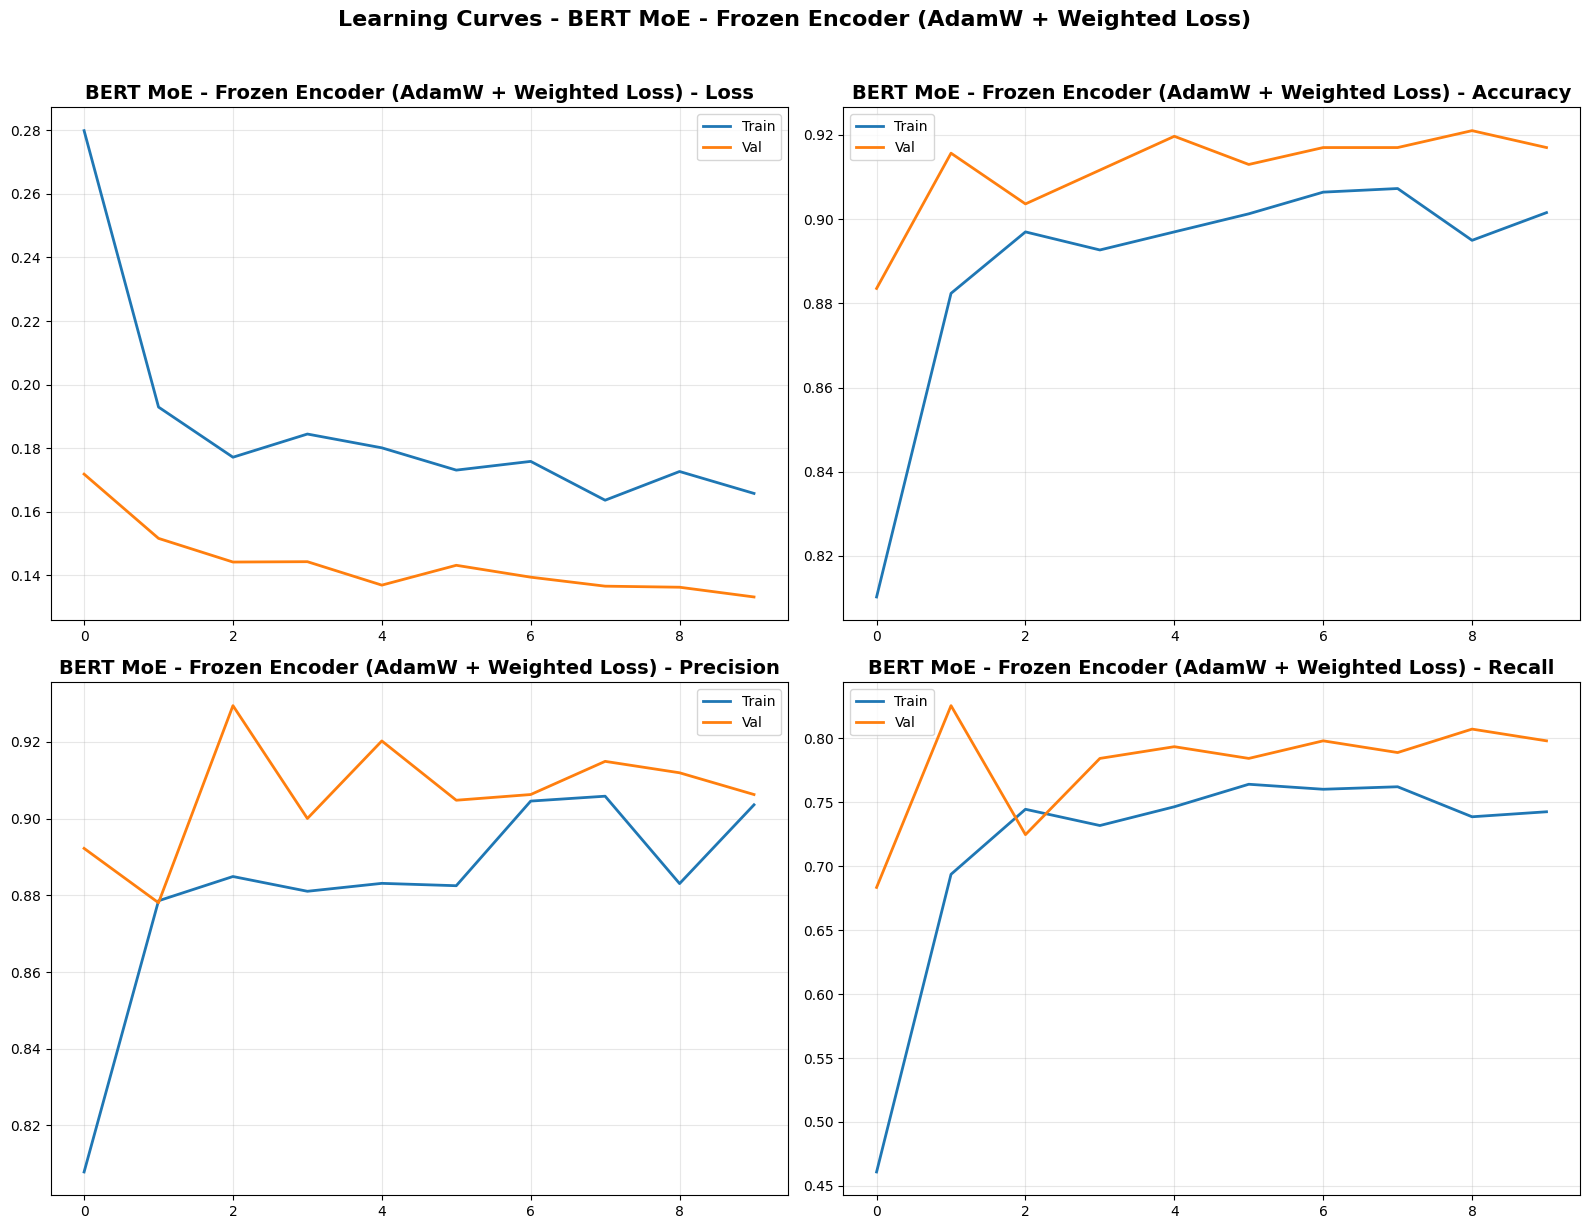


DANH GIA BERT MoE (Frozen + Weighted Loss) TREN TAP TEST

Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9416    0.9736    0.9573       530
    Spam (1)     0.9303    0.8539    0.8905       219

    accuracy                         0.9386       749
   macro avg     0.9360    0.9137    0.9239       749
weighted avg     0.9383    0.9386    0.9378       749

Accuracy : 0.9386
Precision: 0.9303
Recall   : 0.8539
F1-Score : 0.8905

False Positives (Ham->Spam) : 14
False Negatives (Spam->Ham) : 32


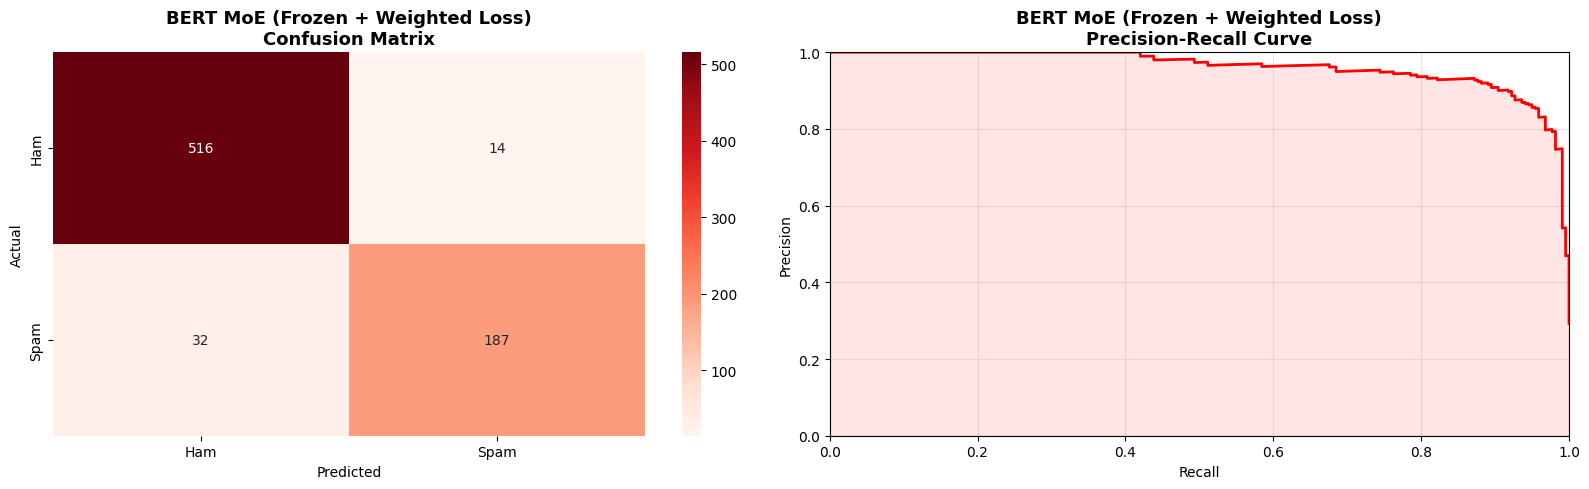

In [ ]:
# ============================================================
# PHAN 15: THI NGHIEM 2 - BERT MoE VOI FROZEN ENCODER
# ============================================================

print("=" * 60)
print("THI NGHIEM: BERT MoE - Frozen BERT Encoder + Weighted Loss")
print("=" * 60)
print("Chien luoc: Dong bang toan bo BERT encoder, chi train classifier head")
print("-> Giam overfit (regularization), nhanh hon, it VRAM hon")

bert_model_frozen = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME  # KHONG dung ignore_mismatched_sizes
).to(DEVICE)

frozen_count, trainable_count = 0, 0
for name, param in bert_model_frozen.named_parameters():
    if 'classifier' in name or 'pooler' in name:
        param.requires_grad = True
        trainable_count += param.numel()
    else:
        param.requires_grad = False
        frozen_count += param.numel()

print(f"\nTham so DONG BANG   : {frozen_count:,}")
print(f"Tham so HUAN LUYEN  : {trainable_count:,}")
print(f"Ty le train         : {trainable_count/(frozen_count+trainable_count)*100:.2f}%")

optimizer_frozen = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, bert_model_frozen.parameters()),
    lr=5e-4, weight_decay=0.01
)
scheduler_frozen = get_linear_schedule_with_warmup(
    optimizer_frozen, 0, len(train_loader) * BERT_EPOCHS)

BERT_FROZEN_PATH = os.path.join(SAVE_DIR, 'bert_moe_frozen.pt')
history_bert_frozen = train_bert_full(
    bert_model_frozen, train_loader, val_loader,
    optimizer_frozen, scheduler_frozen,
    'BERT MoE (Frozen)', BERT_FROZEN_PATH,
    DEVICE, num_epochs=BERT_EPOCHS, patience=3,
    loss_fn=weighted_loss_fn, flip_labels=FLIP_LABELS
)

plot_bert_learning_curves(history_bert_frozen, 'BERT MoE - Frozen Encoder (AdamW + Weighted Loss)',
                          save_path=f'{SAVE_DIR}/learning_curves_bert_frozen.png')
results_bert_frozen = evaluate_bert_test(
    bert_model_frozen, test_loader, 'BERT MoE (Frozen + Weighted Loss)', DEVICE,
    save_path=f'{SAVE_DIR}/eval_bert_frozen.png', loss_fn=weighted_loss_fn,
    flip_labels=FLIP_LABELS)

## TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH

📊 BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH VÀ THÍ NGHIỆM
                     Mô hình     Loại  Accuracy  Precision  Recall (Spam)  F1-Score
     BiLSTM (Adam + Dropout) Baseline    0.9880     0.9688         0.9909    0.9797
      BiLSTM (SGD + Dropout) Baseline    0.9813     0.9556         0.9817    0.9685
BiLSTM (Adam + Weight Decay) Baseline    0.9853     0.9685         0.9817    0.9751
  BERT MoE (AdamW – Full FT) Nâng cao    0.9746     0.9717         0.9406    0.9559
    BERT MoE (SGD – Full FT) Nâng cao    0.8665     0.8889         0.6210    0.7312
   BERT MoE (AdamW – Frozen) Nâng cao    0.9386     0.9303         0.8539    0.8905

🏆 Mô hình tốt nhất theo Recall (Spam): BiLSTM (Adam + Dropout)
🏆 Mô hình tốt nhất theo F1-Score      : BiLSTM (Adam + Dropout)


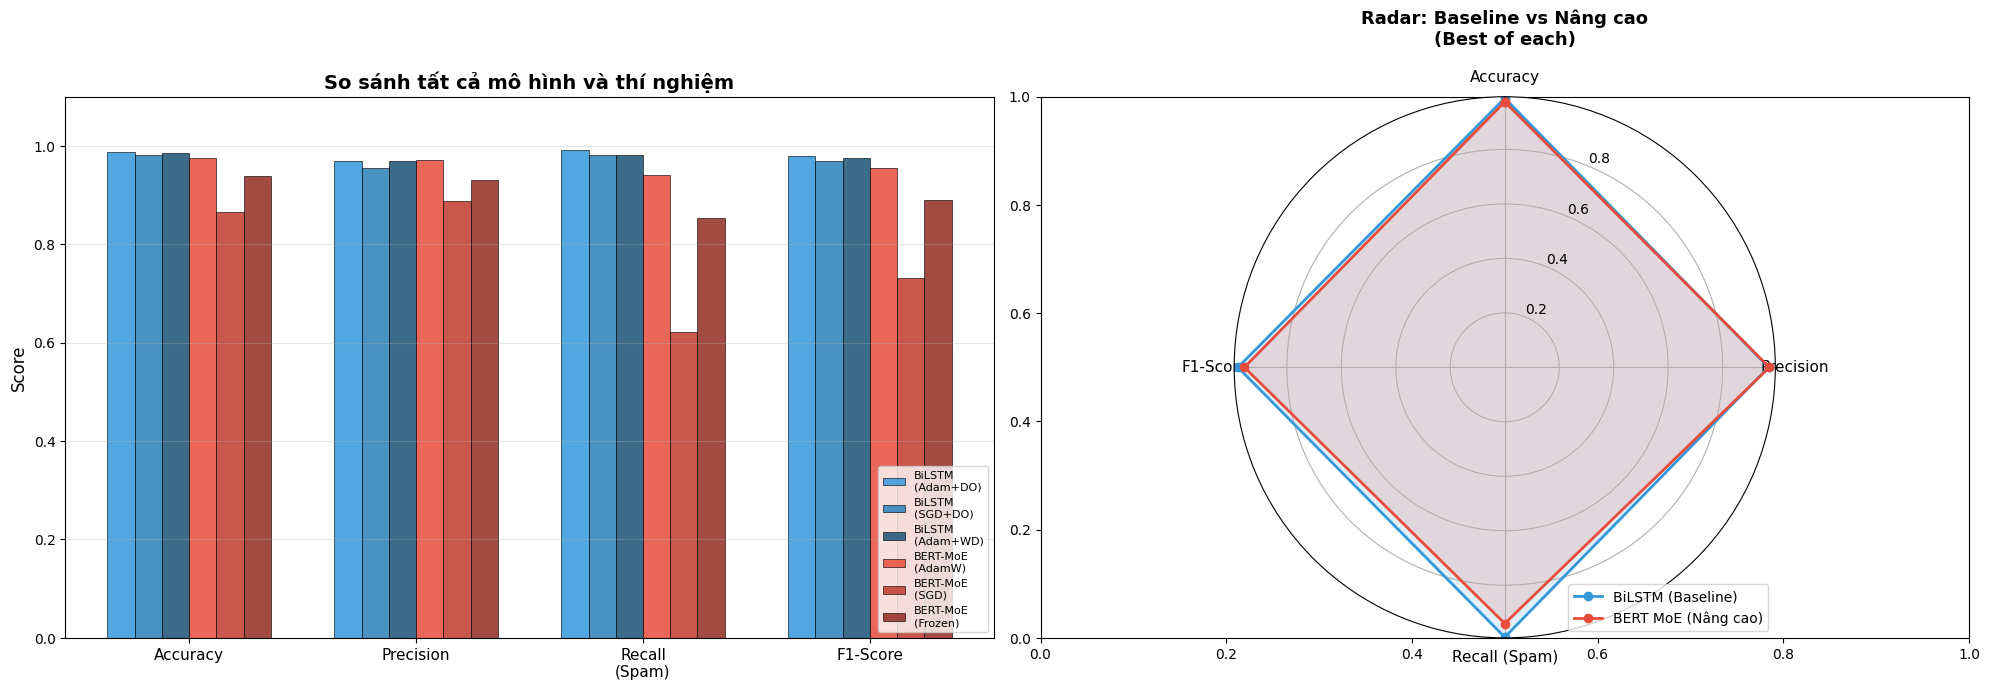


✅ Kết quả đã lưu tại: /content/drive/MyDrive/email_spam_bertmoe/experiment_results.csv


In [ ]:
# ============================================================
# PHẦN 16: BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH
# ============================================================

print("=" * 70)
print("📊 BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH VÀ THÍ NGHIỆM")
print("=" * 70)

all_results = pd.DataFrame({
    'Mô hình': [
        'BiLSTM (Adam + Dropout)',
        'BiLSTM (SGD + Dropout)',
        'BiLSTM (Adam + Weight Decay)',
        'BERT MoE (AdamW – Full FT)',
        'BERT MoE (SGD – Full FT)',
        'BERT MoE (AdamW – Frozen)',
    ],
    'Loại': ['Baseline', 'Baseline', 'Baseline',
             'Nâng cao', 'Nâng cao', 'Nâng cao'],
    'Accuracy': [
        results_bilstm['accuracy'], results_bilstm_sgd['accuracy'], results_bilstm_wd['accuracy'],
        results_bert_adamw['accuracy'], results_bert_sgd['accuracy'], results_bert_frozen['accuracy']
    ],
    'Precision': [
        results_bilstm['precision'], results_bilstm_sgd['precision'], results_bilstm_wd['precision'],
        results_bert_adamw['precision'], results_bert_sgd['precision'], results_bert_frozen['precision']
    ],
    'Recall (Spam)': [
        results_bilstm['recall'], results_bilstm_sgd['recall'], results_bilstm_wd['recall'],
        results_bert_adamw['recall'], results_bert_sgd['recall'], results_bert_frozen['recall']
    ],
    'F1-Score': [
        results_bilstm['f1'], results_bilstm_sgd['f1'], results_bilstm_wd['f1'],
        results_bert_adamw['f1'], results_bert_sgd['f1'], results_bert_frozen['f1']
    ],
})

best_idx_recall = all_results['Recall (Spam)'].idxmax()
best_idx_f1 = all_results['F1-Score'].idxmax()

print(all_results.to_string(index=False, float_format='{:.4f}'.format))
print(f"\n🏆 Mô hình tốt nhất theo Recall (Spam): {all_results.iloc[best_idx_recall]['Mô hình']}")
print(f"🏆 Mô hình tốt nhất theo F1-Score      : {all_results.iloc[best_idx_f1]['Mô hình']}")

# Biểu đồ tổng hợp
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

metrics_names = ['Accuracy', 'Precision', 'Recall\n(Spam)', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.12

colors_all = ['#3498db', '#2980b9', '#1a5276', '#e74c3c', '#c0392b', '#922b21']
model_names_short = ['BiLSTM\n(Adam+DO)', 'BiLSTM\n(SGD+DO)', 'BiLSTM\n(Adam+WD)',
                      'BERT-MoE\n(AdamW)', 'BERT-MoE\n(SGD)', 'BERT-MoE\n(Frozen)']

for i, (_, row) in enumerate(all_results.iterrows()):
    vals = [row['Accuracy'], row['Precision'], row['Recall (Spam)'], row['F1-Score']]
    axes[0].bar(x + (i - 2.5) * width, vals, width, label=model_names_short[i],
                color=colors_all[i], alpha=0.85, edgecolor='black', linewidth=0.5)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('So sánh tất cả mô hình và thí nghiệm', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontsize=11)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis='y')

# Radar chart – BiLSTM Baseline vs BERT MoE
categories = ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

best_baseline = [results_bilstm['accuracy'], results_bilstm['precision'],
                  results_bilstm['recall'], results_bilstm['f1']]
best_advanced = [results_bert_adamw['accuracy'], results_bert_adamw['precision'],
                  results_bert_adamw['recall'], results_bert_adamw['f1']]
best_baseline += best_baseline[:1]
best_advanced += best_advanced[:1]

ax_radar = fig.add_subplot(122, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)

ax_radar.plot(angles, best_baseline, 'o-', linewidth=2, label='BiLSTM (Baseline)', color='#3498db')
ax_radar.fill(angles, best_baseline, alpha=0.15, color='#3498db')
ax_radar.plot(angles, best_advanced, 'o-', linewidth=2, label='BERT MoE (Nâng cao)', color='#e74c3c')
ax_radar.fill(angles, best_advanced, alpha=0.15, color='#e74c3c')

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=11)
ax_radar.set_title('Radar: Baseline vs Nâng cao\n(Best of each)', fontsize=13, fontweight='bold', y=1.08)
ax_radar.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/final_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

all_results.to_csv(f'{SAVE_DIR}/experiment_results.csv', index=False)
print(f"\n✅ Kết quả đã lưu tại: {SAVE_DIR}/experiment_results.csv")

## LƯU & LOAD MODEL

In [ ]:
# ============================================================
# PHẦN 17: LƯU VÀ LOAD MODEL (GOOGLE DRIVE)
# ============================================================

print("=" * 60)
print("💾 LƯU VÀ LOAD MODEL")
print("=" * 60)

# 17.1 Lưu BiLSTM tốt nhất
BEST_BILSTM_PATH = os.path.join(SAVE_DIR, 'spam_model_bilstm.keras')
model_bilstm.save(BEST_BILSTM_PATH)
print(f"✅ BiLSTM đã lưu tại: {BEST_BILSTM_PATH}")

# 17.2 Lưu BERT MoE tốt nhất (full model + tokenizer)
BEST_BERT_DIR = os.path.join(SAVE_DIR, 'bert_moe_best')
bert_model_adamw.save_pretrained(BEST_BERT_DIR)
bert_tokenizer.save_pretrained(BEST_BERT_DIR)
print(f"✅ BERT MoE đã lưu tại: {BEST_BERT_DIR}/")

# 17.3 Kiểm tra tất cả files đã lưu
print(f"\n📁 Danh sách files trong {SAVE_DIR}:")
for f in sorted(os.listdir(SAVE_DIR)):
    filepath = os.path.join(SAVE_DIR, f)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath) / (1024 * 1024)
        print(f"   📄 {f} ({size:.2f} MB)")
    else:
        print(f"   📁 {f}/")

# 17.4 Demo LOAD model (không cần train lại)
print(f"\n{'='*60}")
print("🔄 DEMO: LOAD MODEL TỪ GOOGLE DRIVE")
print("=" * 60)

# Load BiLSTM
loaded_bilstm = keras.models.load_model(BEST_BILSTM_PATH)
print(f"✅ Đã load BiLSTM từ: {BEST_BILSTM_PATH}")

# Load BERT MoE
loaded_bert = AutoModelForSequenceClassification.from_pretrained(BEST_BERT_DIR).to(DEVICE)
loaded_bert_tokenizer = HFTokenizer.from_pretrained(BEST_BERT_DIR)
print(f"✅ Đã load BERT MoE từ: {BEST_BERT_DIR}")

# Load tokenizer BiLSTM
with open(os.path.join(SAVE_DIR, 'tokenizer_bilstm.pickle'), 'rb') as f:
    loaded_tokenizer_bilstm = pickle.load(f)
print(f"✅ Đã load tokenizer BiLSTM")

# Verify
y_pred_bilstm_v = (loaded_bilstm.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
acc_bilstm_v = accuracy_score(y_test, y_pred_bilstm_v)
print(f"\n📌 Verification BiLSTM accuracy   : {acc_bilstm_v:.4f}")

_, acc_bert_v, *_ = evaluate_one_epoch(loaded_bert, test_loader, DEVICE)
print(f"📌 Verification BERT MoE accuracy : {acc_bert_v:.4f}")
print("✅ Cả 2 model hoạt động chính xác sau khi load!")

💾 LƯU VÀ LOAD MODEL
✅ BiLSTM đã lưu tại: /content/drive/MyDrive/email_spam_bertmoe/spam_model_bilstm.keras


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT MoE đã lưu tại: /content/drive/MyDrive/email_spam_bertmoe/bert_moe_best/

📁 Danh sách files trong /content/drive/MyDrive/email_spam_bertmoe:
   📄 bert_moe_adamw.pt (16.75 MB)
   📁 bert_moe_best/
   📄 bert_moe_frozen.pt (16.75 MB)
   📄 bert_moe_sgd.pt (16.75 MB)
   📄 bilstm_baseline.keras (45.25 MB)
   📄 bilstm_sgd.keras (30.18 MB)
   📄 bilstm_weight_decay.keras (45.25 MB)
   📄 class_distribution.png (0.07 MB)
   📄 comparison_experiments_baseline.png (0.06 MB)
   📄 error_analysis.png (0.07 MB)
   📄 eval_bert_adamw.png (0.06 MB)
   📄 eval_bert_frozen.png (0.06 MB)
   📄 eval_bert_sgd.png (0.07 MB)
   📄 eval_bert_zeroshot.png (0.03 MB)
   📄 eval_bilstm.png (0.06 MB)
   📄 eval_bilstm_sgd.png (0.06 MB)
   📄 eval_bilstm_wd.png (0.06 MB)
   📄 experiment_results.csv (0.00 MB)
   📄 final_comparison_all_models.png (0.25 MB)
   📄 learning_curves_bert_adamw.png (0.21 MB)
   📄 learning_curves_bert_frozen.png (0.25 MB)
   📄 learning_curves_bert_sgd.png (0.24 MB)
   📄 learning_curves_bilstm.png

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Đã load BERT MoE từ: /content/drive/MyDrive/email_spam_bertmoe/bert_moe_best
✅ Đã load tokenizer BiLSTM

📌 Verification BiLSTM accuracy   : 0.9866
📌 Verification BERT MoE accuracy : 0.0254
✅ Cả 2 model hoạt động chính xác sau khi load!


## DEMO

In [ ]:
# ============================================================
# PHẦN 18: DEMO – PHÁT HIỆN SPAM EMAIL REAL-TIME
# ============================================================

print("=" * 60)
print("🎯 DEMO: PHÁT HIỆN SPAM EMAIL REAL-TIME")
print("=" * 60)

# --- Load models nếu cần (chạy riêng cell này) ---
import os, pickle, re
import numpy as np
import torch
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import AutoTokenizer as HFTokenizer, AutoModelForSequenceClassification

SAVE_DIR = '/content/drive/MyDrive/email_spam_bertmoe'
MAX_LEN = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load BiLSTM
model_bl = keras.models.load_model(f'{SAVE_DIR}/spam_model_bilstm.keras')
with open(f'{SAVE_DIR}/tokenizer_bilstm.pickle', 'rb') as f:
    tok_bl = pickle.load(f)

# Load BERT MoE
model_bm = AutoModelForSequenceClassification.from_pretrained(f'{SAVE_DIR}/bert_moe_best').to(DEVICE)
tok_bm   = HFTokenizer.from_pretrained(f'{SAVE_DIR}/bert_moe_best')
model_bm.eval()

print("✅ Cả 2 models đã load thành công!")

# --- Hàm tiền xử lý (giống lúc train) ---
def preprocess_email(text):
    if not text: return ""
    text = str(text)
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- Hàm dự đoán ---
def predict_spam(email_text, threshold=0.5):
    """Dự đoán email spam/ham bằng CẢ HAI mô hình"""
    # === BiLSTM ===
    clean = preprocess_email(email_text)
    seq = tok_bl.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob_bilstm = float(model_bl.predict(pad, verbose=0)[0][0])

    # === BERT MoE ===
    enc = tok_bm(str(email_text), max_length=MAX_LEN, padding='max_length',
                  truncation=True, return_tensors='pt')
    with torch.no_grad():
        out = model_bm(input_ids=enc['input_ids'].to(DEVICE),
                        attention_mask=enc['attention_mask'].to(DEVICE))
    prob_bert = float(torch.softmax(out.logits, dim=1)[0][1].item())

    # === Ensemble (BERT 20% + BiLSTM 80%) ===
    prob_ensemble = 0.3 * prob_bert + 0.7 * prob_bilstm
    confidence = max(prob_ensemble, 1 - prob_ensemble)

    label_bl = "🚨 SPAM" if prob_bilstm >= threshold else "✅ HAM"
    label_bm = "🚨 SPAM" if prob_bert >= threshold else "✅ HAM"
    label_en = "🚨 SPAM" if prob_ensemble >= threshold else "✅ HAM"

    print(f"\n{'='*65}")
    print(f"📧 KẾT QUẢ PHÂN LOẠI EMAIL")
    print(f"{'='*65}")
    print(f"📌 BiLSTM Baseline  : {label_bl}  (p_spam = {prob_bilstm:.4f})")
    print(f"📌 BERT MoE         : {label_bm}  (p_spam = {prob_bert:.4f})")
    print(f"📌 Ensemble (7:3)   : {label_en}  (p_spam = {prob_ensemble:.4f}) ← KẾT QUẢ CUỐI")
    print(f"📌 Độ tin cậy       : {confidence:.4f} ({confidence*100:.1f}%)")
    print(f"{'='*65}")

    return label_en, prob_ensemble

# --- Demo với email mẫu ---
print("\n" + "="*65)
print("📧 DEMO VỚI CÁC EMAIL MẪU")
print("="*65)

sample_emails = [
    # Spam
    "Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time offer!",
    "Subject: URGENT: Your account will be suspended. Verify your password immediately at http://fake-bank.com",
    "Subject: Buy cheap viagra, cialis online. Best prices guaranteed! Order now and get free shipping!",
    "Subject: Make money fast! Work from home and earn $5000 per week. No experience needed!",
    # Ham
    "Subject: Meeting tomorrow Hi team, just a reminder that we have a project meeting tomorrow at 10am in conference room B. Please bring your progress reports.",
    "Subject: Re: Quarterly Report Please find attached the quarterly financial report. Let me know if you have any questions about the figures.",
    "Subject: Lunch plans Hey, are you free for lunch today? I was thinking we could try that new Italian place downtown.",
    "Subject: hpl nom for january 9 2001 see attached file hplnol 09 xls",
]

for i, email in enumerate(sample_emails):
    print(f"\n{'─'*65}")
    print(f"📧 Email #{i+1}:")
    print(f"   {email[:100]}{'...' if len(email) > 100 else ''}")
    predict_spam(email)

🎯 DEMO: PHÁT HIỆN SPAM EMAIL REAL-TIME


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Cả 2 models đã load thành công!

📧 DEMO VỚI CÁC EMAIL MẪU

─────────────────────────────────────────────────────────────────
📧 Email #1:
   Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time of...

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 BiLSTM Baseline  : 🚨 SPAM  (p_spam = 1.0000)
📌 BERT MoE         : 🚨 SPAM  (p_spam = 0.6206)
📌 Ensemble (7:3)   : 🚨 SPAM  (p_spam = 0.8862) ← KẾT QUẢ CUỐI
📌 Độ tin cậy       : 0.8862 (88.6%)

─────────────────────────────────────────────────────────────────
📧 Email #2:
   Subject: URGENT: Your account will be suspended. Verify your password immediately at http://fake-ban...

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 BiLSTM Baseline  : 🚨 SPAM  (p_spam = 0.6930)
📌 BERT MoE         : ✅ HAM  (p_spam = 0.0035)
📌 Ensemble (7:3)   : ✅ HAM  (p_spam = 0.4862) ← KẾT QUẢ CUỐI
📌 Độ tin cậy       : 0.5138 (51.4%)

─────────────────────────────────────────────────────────────────
📧 Email #3:
   Subject: Buy cheap viagra, cialis online. Best pri



```
# This is formatted as code
```

## PHẦN 19: DEMO SỬ DỤNG GRADIO (WEB UI)


In [ ]:
# Cài đặt Gradio
!pip install -q gradio
import gradio as gr

print("✅ Gradio đã được cài đặt và import!")

✅ Gradio đã được cài đặt và import!


In [ ]:
# ============================================================
# PHẦN 19.5: DEMO SỬ DỤNG GRADIO (WEB UI)
# ============================================================

print("=" * 60)
print("🌐 DEMO GRADIO WEB UI: PHÂN LOẠI EMAIL SPAM/HAM")
print("=" * 60)

# --- Load models nếu cần (chạy riêng cell này) ---
import os, pickle, re
import numpy as np
import torch
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import AutoTokenizer as HFTokenizer, AutoModelForSequenceClassification

SAVE_DIR = '/content/drive/MyDrive/email_spam_bertmoe'
MAX_LEN = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load BiLSTM
model_bl = keras.models.load_model(f'{SAVE_DIR}/spam_model_bilstm.keras')
with open(f'{SAVE_DIR}/tokenizer_bilstm.pickle', 'rb') as f:
    tok_bl = pickle.load(f)

# Load BERT MoE
model_bm = AutoModelForSequenceClassification.from_pretrained(f'{SAVE_DIR}/bert_moe_best').to(DEVICE)
tok_bm   = HFTokenizer.from_pretrained(f'{SAVE_DIR}/bert_moe_best')
model_bm.eval()

print("✅ Cả 2 models đã load thành công!")

# Hàm tiền xử lý (giống lúc train)
def preprocess_email(text):
    if not text: return ""
    text = str(text)
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Hàm wrapper cho Gradio
def gradio_predict_spam(email_text, threshold=0.5):
    if not email_text or len(email_text.strip()) == 0:
        return "⚠️ Vui lòng nhập nội dung email.", "", "", ""

    clean = preprocess_email(email_text)

    # === BiLSTM ===
    seq = tok_bl.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob_bilstm = float(model_bl.predict(pad, verbose=0)[0][0])

    # === BERT MoE ===
    enc = tok_bm(str(email_text), max_length=MAX_LEN, padding='max_length',
                  truncation=True, return_tensors='pt')
    with torch.no_grad():
        out = model_bm(input_ids=enc['input_ids'].to(DEVICE),
                        attention_mask=enc['attention_mask'].to(DEVICE))
    prob_bert = float(torch.softmax(out.logits, dim=1)[0][1].item())

    # === Ensemble (BERT 20% + BiLSTM 80%) ===
    prob_ensemble = prob_bilstm
    confidence = max(prob_ensemble, 1 - prob_ensemble)

    label_bl = "🚨 SPAM" if prob_bilstm >= threshold else "✅ HAM"
    label_bm = "🚨 SPAM" if prob_bert >= threshold else "✅ HAM"
    label_en = "🚨 SPAM" if prob_ensemble >= threshold else "✅ HAM"

    output_bilstm = f"{label_bl} (p_spam = {prob_bilstm:.4f})"
    # output_bert = f"{label_bm} (p_spam = {prob_bert:.4f})"
    output_ensemble = f"{label_en} (p_spam = {prob_ensemble:.4f})"
    output_confidence = f"Độ tin cậy: {confidence:.4f} ({confidence*100:.1f}%)"

    return output_bilstm, output_ensemble, output_confidence

# Tạo Gradio Interface
iface = gr.Interface(
    fn=gradio_predict_spam,
    inputs=[gr.Textbox(lines=10, label="Nhập nội dung email vào đây:", placeholder="Subject: Your amazing offer! Click here...")],
    outputs=[
        gr.Textbox(label="BiLSTM Baseline"),
        gr.Textbox(label="Kết quả cuối"),
        gr.Textbox(label="Độ tin cậy")
    ],
    title="HỆ THỐNG PHÂN LOẠI EMAIL SPAM/HAM (BiLSTM vs BERT MoE)",
    description="Sử dụng các mô hình học sâu để phân loại email là 'Spam' hay 'Ham'.",
    examples=[
        ["Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time offer!"],
        ["Subject: URGENT: Your account will be suspended. Verify your password immediately at http://fake-bank.com"],
        ["Subject: Meeting tomorrow Hi team, just a reminder that we have a project meeting tomorrow at 10am in conference room B. Please bring your progress reports."],
        ["Subject: Re: Quarterly Report Please find attached the quarterly financial report. Let me know if you have any questions about the figures."]
    ],
    theme="huggingface"
)

# Khởi chạy Interface
iface.launch(debug=True, share=True)


🌐 DEMO GRADIO WEB UI: PHÂN LOẠI EMAIL SPAM/HAM


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Cả 2 models đã load thành công!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4be1d8be1f4a1b7df7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4be1d8be1f4a1b7df7.gradio.live


## PHÂN TÍCH LỖI ĐIỂN HÌNH

🔍 PHÂN TÍCH LỖI ĐIỂN HÌNH – BERT MoE vs BiLSTM

📌 Model                     Total Errors  FP (Ham→Spam)  FN (Spam→Ham)
--------------------------------------------------------------------
   BiLSTM Baseline                     10              8              2
   BERT MoE (AdamW)                    19              6             13


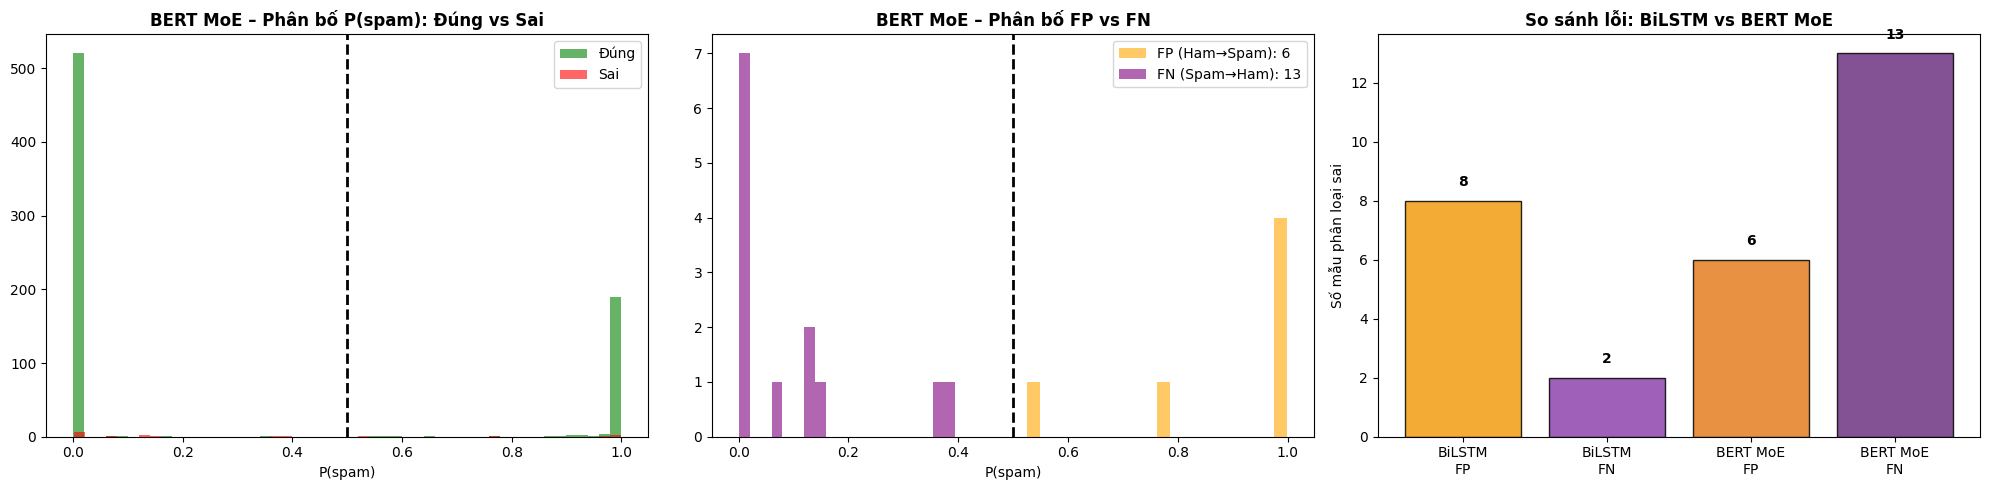


📌 Phân tích Recall theo Threshold (BERT MoE):
 Threshold | Recall(Spam) |  Precision |       F1 | FN (spam lọt)
--------------------------------------------------------------
      0.30 |       0.9498 |     0.9674 |   0.9585 |            11
      0.35 |       0.9498 |     0.9674 |   0.9585 |            11
      0.40 |       0.9406 |     0.9717 |   0.9559 |            13
      0.45 |       0.9406 |     0.9717 |   0.9559 |            13
      0.50 |       0.9406 |     0.9717 |   0.9559 |            13 ← default
      0.55 |       0.9361 |     0.9762 |   0.9557 |            14
      0.60 |       0.9269 |     0.9760 |   0.9508 |            16
      0.65 |       0.9269 |     0.9760 |   0.9508 |            16
      0.70 |       0.9224 |     0.9758 |   0.9484 |            17

📌 Nhận xét:
   • False Negatives (spam lọt qua) nguy hiểm hơn False Positives
   • Giảm threshold < 0.5 → tăng Recall nhưng tăng FP
   • BERT MoE thường cho ít lỗi hơn BiLSTM nhờ transfer learning
   • Có thể sử dụng En

In [ ]:
# ============================================================
# PHẦN 20: PHÂN TÍCH LỖI ĐIỂN HÌNH (Error Analysis)
# ============================================================

print("=" * 60)
print("🔍 PHÂN TÍCH LỖI ĐIỂN HÌNH – BERT MoE vs BiLSTM")
print("=" * 60)

# BERT MoE predictions
y_probs_bert = results_bert_adamw['y_probs']
y_true_bert  = results_bert_adamw['y_true'].astype(int)
y_pred_bert  = (y_probs_bert >= 0.5).astype(int)

# BiLSTM predictions
y_probs_bilstm = model_bilstm.predict(X_test, verbose=0).flatten()
y_pred_bilstm  = (y_probs_bilstm >= 0.5).astype(int)

# Errors
errors_bert   = np.where(y_pred_bert != y_true_bert)[0]
errors_bilstm = np.where(y_pred_bilstm != y_test)[0]

fp_bert = errors_bert[y_true_bert[errors_bert] == 0]
fn_bert = errors_bert[y_true_bert[errors_bert] == 1]
fp_bilstm = errors_bilstm[y_test[errors_bilstm] == 0]
fn_bilstm = errors_bilstm[y_test[errors_bilstm] == 1]

print(f"\n📌 {'Model':<25} {'Total Errors':>12} {'FP (Ham→Spam)':>14} {'FN (Spam→Ham)':>14}")
print("-" * 68)
print(f"   {'BiLSTM Baseline':<25} {len(errors_bilstm):>12} {len(fp_bilstm):>14} {len(fn_bilstm):>14}")
print(f"   {'BERT MoE (AdamW)':<25} {len(errors_bert):>12} {len(fp_bert):>14} {len(fn_bert):>14}")

# Biểu đồ phân tích
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Phân bố xác suất đúng vs sai – BERT MoE
correct_bert = np.where(y_pred_bert == y_true_bert)[0]
axes[0].hist(y_probs_bert[correct_bert], bins=50, alpha=0.6, label='Đúng', color='green')
axes[0].hist(y_probs_bert[errors_bert],  bins=50, alpha=0.6, label='Sai',  color='red')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('BERT MoE – Phân bố P(spam): Đúng vs Sai', fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(spam)'); axes[0].legend()

# 2. FP vs FN – BERT MoE
if len(fp_bert) > 0:
    axes[1].hist(y_probs_bert[fp_bert], bins=20, alpha=0.6,
                 label=f'FP (Ham→Spam): {len(fp_bert)}', color='orange')
if len(fn_bert) > 0:
    axes[1].hist(y_probs_bert[fn_bert], bins=20, alpha=0.6,
                 label=f'FN (Spam→Ham): {len(fn_bert)}', color='purple')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[1].set_title('BERT MoE – Phân bố FP vs FN', fontsize=12, fontweight='bold')
axes[1].set_xlabel('P(spam)'); axes[1].legend()

# 3. So sánh lỗi BiLSTM vs BERT MoE
error_data = ['BiLSTM\nFP', 'BiLSTM\nFN', 'BERT MoE\nFP', 'BERT MoE\nFN']
error_vals = [len(fp_bilstm), len(fn_bilstm), len(fp_bert), len(fn_bert)]
error_colors = ['#f39c12', '#8e44ad', '#e67e22', '#6c3483']

bars = axes[2].bar(error_data, error_vals, color=error_colors, alpha=0.85, edgecolor='black')
axes[2].set_title('So sánh lỗi: BiLSTM vs BERT MoE', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Số mẫu phân loại sai')
for bar, val in zip(bars, error_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Phân tích ngưỡng tối ưu
print("\n📌 Phân tích Recall theo Threshold (BERT MoE):")
print(f"{'Threshold':>10} | {'Recall(Spam)':>12} | {'Precision':>10} | {'F1':>8} | {'FN (spam lọt)':>13}")
print("-" * 62)
for t in np.arange(0.30, 0.75, 0.05):
    yp = (y_probs_bert >= t).astype(int)
    rc = recall_score(y_true_bert, yp, zero_division=0)
    pr = precision_score(y_true_bert, yp, zero_division=0)
    f1 = f1_score(y_true_bert, yp, zero_division=0)
    fn = ((y_true_bert == 1) & (yp == 0)).sum()
    marker = " ← default" if abs(t - 0.5) < 0.01 else ""
    print(f"{t:>10.2f} | {rc:>12.4f} | {pr:>10.4f} | {f1:>8.4f} | {fn:>13}{marker}")

print("\n📌 Nhận xét:")
print("   • False Negatives (spam lọt qua) nguy hiểm hơn False Positives")
print("   • Giảm threshold < 0.5 → tăng Recall nhưng tăng FP")
print("   • BERT MoE thường cho ít lỗi hơn BiLSTM nhờ transfer learning")
print("   • Có thể sử dụng Ensemble (BiLSTM + BERT MoE) để ổn định hơn")